<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 7 — Filtrado de señales II: Filtros adaptativos y Transformada Wavelet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Filtrado de señales II — Filtros adaptativos (LMS) y Transformada Wavelet aplicados a ECG </font><br>
<font color="#7F000E" size=3> Laboratorio práctico · Duración: 2 horas (120 min) </font><br>
</div>

| Campo | Completar |
|---|---|
| **Nombre del estudiante** | ✍️ Jairo Villalobos Vargas, Wilber Mauricio Zenteno Castilla, Mateo Torres Ricalde, Miguel Angel Tello Ocaña|
| **Fecha** | ✍️ 7/10/2026 |

---

> **Enfoque del laboratorio:** *"Primero observamos la señal, luego la contaminamos, analizamos cómo se degrada, aplicamos diferentes técnicas de filtrado y finalmente evaluamos qué ocurrió con la señal."*

## 🎯 Resultados de aprendizaje

Al finalizar el laboratorio, serás capaz de:

1. Identificar una señal ECG en datos adquiridos mediante **BITalino (r)evolution / OpenSignals**.
2. Diferenciar **señal fisiológica**, **interferencia** y **ruido**.
3. Generar artificialmente señales contaminadas de forma controlada.
4. Aplicar filtros digitales (pasa-banda y notch).
5. Comparar métodos de filtrado con criterios visuales y cuantitativos.
6. Comprender conceptualmente el **filtrado adaptativo** (algoritmo LMS).
7. Comprender para qué sirve la **Transformada Wavelet**.
8. Evaluar la recuperación de una señal ECG.
9. Comunicar los resultados mediante una **infografía**.

## ⏱️ Agenda de la sesión (120 min)

| Bloque | Contenido | Duración | Minutos |
|---|---|---:|---:|
| 1 | Introducción y exploración de datos | 15 min | 0 – 15 |
| 2 | Señal ECG original | 15 min | 15 – 30 |
| 3 | Contaminación artificial + análisis en frecuencia | 20 min | 30 – 50 |
| 4 | Aplicación de filtros convencionales + métricas | 25 min | 50 – 75 |
| 5 | Filtros adaptativos y Wavelet | 20 min | 75 – 95 |
| 6 | Comparación e interpretación | 10 min | 95 – 105 |
| 7 | Retroalimentación, síntesis e infografía | 15 min | 105 – 120 |

> 🔁 **Los últimos 30 minutos (min 90 – 120)** se dedican a **revisión, discusión y retroalimentación**: cierre de la discusión Wavelet, comparación global (Bloque 6), preguntas, síntesis *SUMARIZE* e infografía (Bloque 7). En este tramo **no se introducen conceptos nuevos**.

**Patrón de trabajo en cada sección:**

```text
CONCEPTO → EXPLICACIÓN BREVE → CÓDIGO → GRÁFICA → INTERPRETACIÓN → PREGUNTA AL ESTUDIANTE
```

---
# 🟦 BLOQUE 1 — Introducción y exploración de datos *(15 min)*

## 1.1 Librerías

| Librería | Para qué la usamos |
|---|---|
| `numpy` | Operaciones numéricas con vectores: eje temporal, senoides, ruido, FFT. |
| `pandas` | Leer el archivo de texto como tabla y explorar columnas/estadísticas. |
| `matplotlib` | Graficar señales en tiempo y frecuencia. |
| `scipy.signal` | Diseñar y aplicar filtros digitales (`butter`, `iirnotch`, `filtfilt`, `freqz`). |
| `pywt` (PyWavelets) | Transformada Wavelet discreta: descomposición y *denoising*. |

In [1]:
# Si trabajas en Google Colab y PyWavelets no está instalado, descomenta la siguiente línea:
# !pip install PyWavelets

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import pywt

# Estilo de gráficos uniforme para todo el laboratorio
plt.rcParams.update({
    "figure.figsize": (14, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titleweight": "bold",
    "font.size": 11,
})

# Semilla: garantiza que el ruido "aleatorio" sea el mismo en cada ejecución (reproducibilidad)
rng = np.random.default_rng(seed=42)

print("NumPy:", np.__version__, "| Pandas:", pd.__version__, "| PyWavelets:", pywt.__version__)

NumPy: 2.1.3 | Pandas: 2.2.3 | PyWavelets: 1.8.0


## 1.2 Archivo de ECG en actividad física (formato OpenSignals)

El archivo `actividad_fisica_d1.txt` fue obtenido mediante BITalino y OpenSignals. Este contiene una cabecera con la información de la adquisición y las muestras registradas durante la prueba de actividad física.

Según la cabecera, la señal fue adquirida con una frecuencia de muestreo de 1000 Hz y una resolución de 10 bits. El ECG se almacenó en el canal analógico A1.

| Columna | Significado | ¿Es ECG? |
|---|---|---|
| `nSeq` | Contador de secuencia de paquetes | No |
| `I1`, `I2` | Entradas digitales | No |
| `O1`, `O2` | Salidas digitales | No |
| `A1` | Canal analógico donde se registró el ECG | Sí |

In [2]:
CONDICION = "Actividad física"
RUTA_ARCHIVO = "actividad_fisica_d1.txt"

if not os.path.exists(RUTA_ARCHIVO):
    try:
        from google.colab import files
        print("Seleccione el archivo:", RUTA_ARCHIVO)
        files.upload()
    except ImportError:
        print(f"No se encontró '{RUTA_ARCHIVO}'. Colóquelo en la misma carpeta que este notebook.")

print("Condición analizada:", CONDICION)
print("Archivo disponible:", os.path.exists(RUTA_ARCHIVO))

Condición analizada: Actividad física
Archivo disponible: True


### Leer la cabecera

Leemos solo las líneas iniciales que empiezan con `#` y extraemos los metadatos **directamente del archivo** (no los suponemos).

In [3]:
# Guardar las líneas de la cabecera
lineas_cabecera = []

with open(RUTA_ARCHIVO, "r", encoding="utf-8", errors="ignore") as archivo:
    for linea in archivo:
        if linea.startswith("#"):
            lineas_cabecera.append(linea.strip())
        else:
            break

print("Cabecera del archivo:\n")

for linea in lineas_cabecera:
    print(linea[:300] + ("..." if len(linea) > 300 else ""))

# Buscar los metadatos guardados en formato JSON
metadatos = {}

for linea in lineas_cabecera:
    contenido = linea.lstrip("#").strip()

    if contenido.startswith("{"):
        try:
            diccionario = json.loads(contenido)
            metadatos = list(diccionario.values())[0]
        except json.JSONDecodeError:
            print("No se pudo interpretar la cabecera.")

# Parámetros obtenidos directamente del archivo
Fs = int(metadatos.get("sampling rate", 1000))

columnas = metadatos.get(
    "column",
    ["nSeq", "I1", "I2", "O1", "O2", "A1"]
)

resoluciones = metadatos.get("resolution", [])
CANAL_ECG = "A1"

if len(resoluciones) == len(columnas):
    resolucion_ECG = resoluciones[columnas.index(CANAL_ECG)]
else:
    resolucion_ECG = 10

print("\nCondición registrada:", CONDICION)
print("Frecuencia de muestreo:", Fs, "Hz")
print("Columnas:", columnas)
print("Canal ECG:", CANAL_ECG)
print("Resolución del ECG:", resolucion_ECG, "bits")

Cabecera del archivo:

# OpenSignals Text File Format. Version 1
# {"98:D3:41:FE:16:36": {"position": 0, "device": "bitalino_rev", "device name": "98:D3:41:FE:16:36", "device connection": "BTH98:D3:41:FE:16:36", "sampling rate": 1000, "resolution": [4, 1, 1, 1, 1, 10], "firmware version": 1282, "comments": "", "keywords": "", "mode": 0, "sync interval": 2, "date"...
# EndOfHeader

Condición registrada: Actividad física
Frecuencia de muestreo: 1000 Hz
Columnas: ['nSeq', 'I1', 'I2', 'O1', 'O2', 'A1']
Canal ECG: A1
Resolución del ECG: 10 bits


### Leer los datos

In [4]:
datos = pd.read_csv(
    RUTA_ARCHIVO,
    sep=r"\s+",
    comment="#",
    header=None
)

datos = datos.iloc[:, :len(columnas)]
datos.columns = columnas

numero_muestras = len(datos)
Ts = 1 / Fs
duracion_total = numero_muestras / Fs

print("Condición analizada:", CONDICION)
print("Número de muestras:", numero_muestras)
print("Frecuencia de muestreo:", Fs, "Hz")
print(f"Periodo de muestreo: {Ts*1000:.1f} ms")
print(f"Duración total: {duracion_total:.2f} s")
print("Columnas:", list(datos.columns))

datos.head(10)

Condición analizada: Actividad física
Número de muestras: 27150
Frecuencia de muestreo: 1000 Hz
Periodo de muestreo: 1.0 ms
Duración total: 27.15 s
Columnas: ['nSeq', 'I1', 'I2', 'O1', 'O2', 'A1']


,nSeq,I1,I2,O1,O2,A1
0,0,0,0,0,0,569
1,1,0,0,0,0,569
2,2,0,0,0,0,570
3,3,0,0,0,0,571
4,4,0,0,0,0,571
5,5,0,0,0,0,570
6,6,0,0,0,0,569
7,7,0,0,0,0,569
8,8,0,0,0,0,569
9,9,0,0,0,0,568


In [5]:
# Estadísticas básicas de todas las columnas
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
nSeq,27150.0,7.499484,4.609633,0.0,3.25,7.0,11.0,15.0
I1,27150.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
I2,27150.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
O1,27150.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
O2,27150.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
A1,27150.0,508.692007,37.788279,364.0,489.00,502.0,544.0,582.0


### ¿Por qué **no** usar `nSeq` como eje temporal?

`nSeq` es un **contador de paquetes** que se reinicia periódicamente (en BITalino es un contador de 4 bits: 0, 1, …, 15, 0, 1, …). Sirve para **detectar muestras perdidas** durante la transmisión, pero **no** es el tiempo absoluto. El eje temporal correcto se construye a partir del índice de muestra y la frecuencia de muestreo:

$$t[n] = \frac{n}{F_s}$$

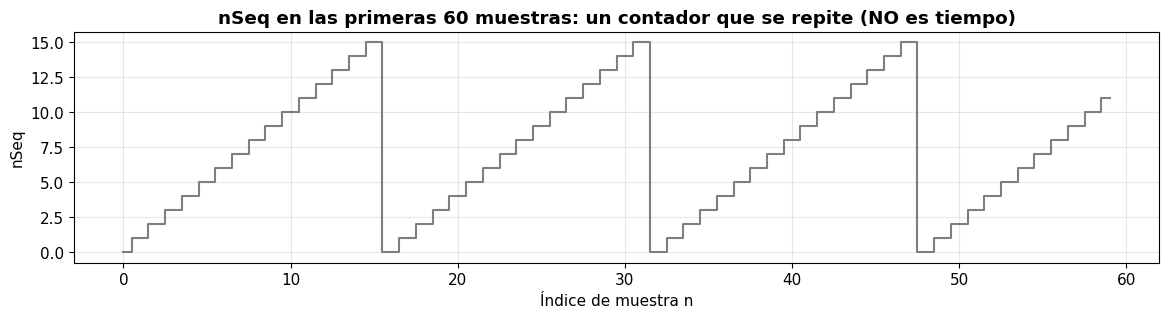

El contador va de 0 a 15.
Muestras con salto distinto de 1 (posibles pérdidas): 0


In [6]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.step(np.arange(60), datos["nSeq"].values[:60], where="mid", color="tab:gray")
ax.set_title("nSeq en las primeras 60 muestras: un contador que se repite (NO es tiempo)")
ax.set_xlabel("Índice de muestra n"); ax.set_ylabel("nSeq")
plt.show()

# Verificación de paquetes perdidos: el salto esperado entre muestras consecutivas es 1 (módulo del contador)
modulo = int(datos["nSeq"].max()) + 1
saltos = np.diff(datos["nSeq"].values) % modulo
print(f"El contador va de 0 a {modulo-1}.")
print("Muestras con salto distinto de 1 (posibles pérdidas):", int(np.sum(saltos != 1)))

### ❓ Pregunta al estudiante (Bloque 1)

Según la cabecera, ¿cuántos niveles distintos puede tomar el canal `A1`? (Pista: $2^{\text{bits}}$). ¿Por qué es útil verificar `nSeq` antes de analizar la señal?

✍️ **Respuesta:**

El canal A1 presenta una resolución de 10 bits, por lo que puede representar 2^10=1024 niveles diferentes. Verificar `nSeq` permite comprobar si las muestras fueron registradas de manera continua o si se perdió algún dato durante la transmisión. En nuestro archivo no se encontraron saltos diferentes de uno, por lo que no se detectaron muestras perdidas.


---
# 🟦 BLOQUE 2 — Señal ECG original *(15 min)*

## 2.1 Conceptos mínimos

- **Amplitud**: magnitud de la señal (aquí, en mV).
- **Tiempo**: eje horizontal construido con $t = n/F_s$.
- **Frecuencia de muestreo** $F_s$: muestras por segundo (1000 Hz → 1000 muestras/s).
- **Periodo de muestreo** $T_s = 1/F_s$: tiempo entre muestras (1 ms).
- **Morfología ECG**: forma característica de cada latido (onda P, complejo QRS, onda T).
- **Ruido**: componente aleatoria, no deseada, generalmente de banda ancha.
- **Interferencia**: componente no deseada con origen y estructura identificables (p. ej., la red eléctrica a una frecuencia fija).

## 2.2 Extracción del canal A1 y conversión a milivoltios

El canal A1 contiene los valores digitales correspondientes a la señal ECG. Para poder trabajar con una unidad física, estos valores se convirtieron a milivoltios mediante la resolución del canal y los parámetros del sensor ECG.

In [7]:
VCC = 3.3
G_ECG = 1100

# Extraer el canal ECG
ecg_adc = datos[CANAL_ECG].to_numpy(dtype=float)

# Convertir los valores digitales a milivoltios
ecg_mV = (
    (ecg_adc / 2**resolucion_ECG) - 0.5
) * VCC / G_ECG * 1000

# Centrar la señal alrededor de cero
ecg_original = ecg_mV - np.mean(ecg_mV)

# Crear el eje temporal
t = np.arange(len(ecg_original)) / Fs

print("Condición analizada:", CONDICION)
print("Canal utilizado:", CANAL_ECG)
print(f"Amplitud mínima: {ecg_original.min():.3f} mV")
print(f"Amplitud máxima: {ecg_original.max():.3f} mV")
print(f"Desviación estándar: {np.std(ecg_original):.3f} mV")

Condición analizada: Actividad física
Canal utilizado: A1
Amplitud mínima: -0.424 mV
Amplitud máxima: 0.215 mV
Desviación estándar: 0.111 mV


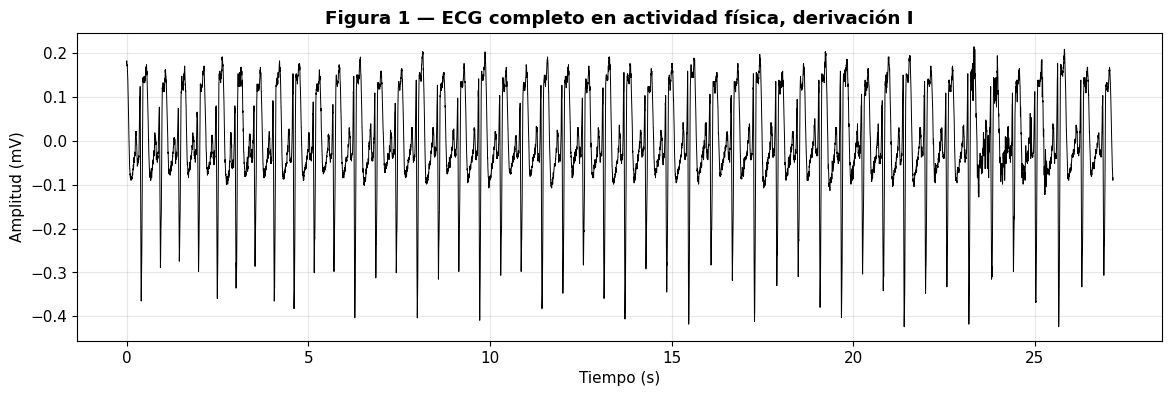

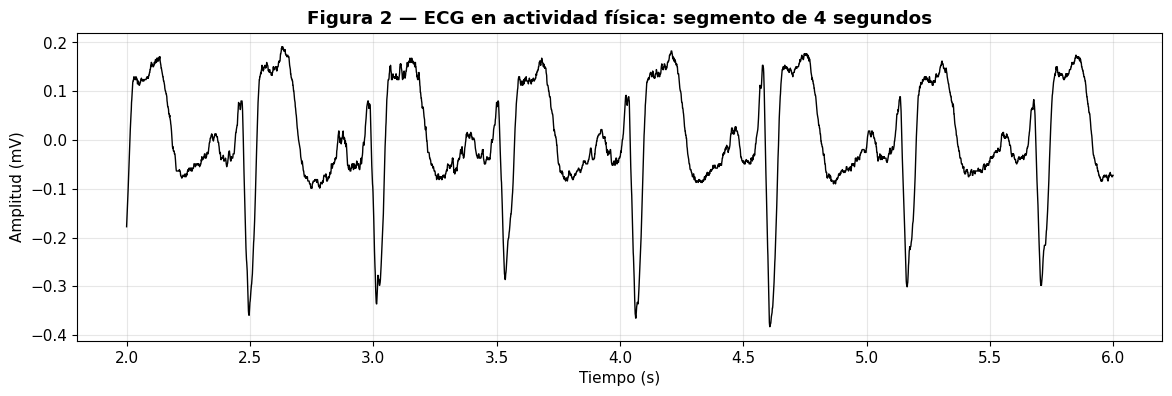

In [8]:
DURACION_ZOOM = 4.0
T_INICIO_ZOOM = 2.0

zoom = (
    (t >= T_INICIO_ZOOM)
    & (t < T_INICIO_ZOOM + DURACION_ZOOM)
)

# ECG completo
plt.figure(figsize=(14, 4))
plt.plot(t, ecg_original, color="black", linewidth=0.7)
plt.title(f"Figura 1 — ECG completo en {CONDICION.lower()}, derivación I")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.show()

# Segmento de cuatro segundos
plt.figure(figsize=(14, 4))
plt.plot(
    t[zoom],
    ecg_original[zoom],
    color="black",
    linewidth=1
)
plt.title(f"Figura 2 — ECG en {CONDICION.lower()}: segmento de 4 segundos")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.show()

### 🔎 Interpretación

- En la primera figura se observa el registro completo del ECG durante actividad física, con una duración de 27,15 segundos.
- En el registro completo se observan complejos QRS más próximos entre sí y mayores variaciones de amplitud. También se aprecia una línea de base menos estable y más ruido que en una adquisición en reposo, lo cual es esperable porque el movimiento puede afectar el contacto de los electrodos.
- La señal es real y todavía contiene ruido propio de la adquisición.

### ❓ Pregunta al estudiante (Bloque 2)

A partir de la Figura 2, estima la frecuencia cardiaca contando los complejos QRS en la ventana.

✍️ **Respuesta:**

En el segmento de cuatro segundos se identificaron aproximadamente 7 complejos QRS. La frecuencia cardiaca se estimó mediante el siguiente cálculo:

$$FC=rac{7}{4}	imes 60=105\ 	ext{latidos por minuto}$$

Por lo tanto, para la ventana seleccionada se obtuvo una frecuencia cardiaca aproximada de 105 latidos por minuto.

---
# 🟦 BLOQUE 3 — Contaminación artificial de la señal *(20 min)*

## 3.1 ¿Por qué contaminar artificialmente?

Para **evaluar un filtro necesitamos saber cuál es la "respuesta correcta"**. Si contaminamos nosotros mismos la señal con componentes **conocidas**, podemos comparar la señal filtrada con la original y medir qué tan bien se recuperó.

$$ECG_{contaminado} = ECG_{original} + \text{interferencia}_1 + \text{interferencia}_2 + \text{ruido gaussiano}$$

> ⚠️ **Importante:** esta es una **contaminación artificial y controlada con fines didácticos**. Las frecuencias elegidas **no** representan todas las fuentes reales de ruido de un ECG (en la práctica también hay deriva de línea de base, artefactos de movimiento, ruido muscular/EMG, mal contacto de electrodos, etc.).

**Elección de frecuencias:** en Perú la red eléctrica opera a **60 Hz**, por eso usamos $f_1 = 60$ Hz y su segundo armónico $f_2 = 120$ Hz. Si quieres reproducir el caso europeo, cambia a 50 y 100 Hz. **Todos los parámetros son modificables.**

In [9]:
# =================== PARÁMETROS MODIFICABLES ===================
f1 = 60        # Hz — interferencia 1 (red eléctrica en Perú)
f2 = 120       # Hz — interferencia 2 (armónico de la red)

escala = np.std(ecg_original)   # referencia de amplitud de la propia señal
amplitud_1 = 1.0 * escala       # amplitud de la interferencia 1 (mV)
amplitud_2 = 0.6 * escala       # amplitud de la interferencia 2 (mV)
sigma_ruido = 0.3 * escala      # desviación estándar del ruido gaussiano (mV)
# ===============================================================

# Fases aleatorias (pero reproducibles): las interferencias reales no empiezan en fase cero
fase_1, fase_2 = rng.uniform(0, 2 * np.pi, size=2)

ruido_senoidal_1 = amplitud_1 * np.sin(2 * np.pi * f1 * t + fase_1)
ruido_senoidal_2 = amplitud_2 * np.sin(2 * np.pi * f2 * t + fase_2)
ruido_gaussiano  = rng.normal(0, sigma_ruido, size=len(t))

ecg_contaminado = (
    ecg_original
    + ruido_senoidal_1
    + ruido_senoidal_2
    + ruido_gaussiano
)

print(f"Interferencia 1: {f1} Hz, amplitud {amplitud_1:.3f} mV")
print(f"Interferencia 2: {f2} Hz, amplitud {amplitud_2:.3f} mV")
print(f"Ruido gaussiano: sigma = {sigma_ruido:.3f} mV")

Interferencia 1: 60 Hz, amplitud 0.111 mV
Interferencia 2: 120 Hz, amplitud 0.066 mV
Ruido gaussiano: sigma = 0.033 mV


## 3.2 Visualización de cada componente

Usamos una ventana de **1 segundo** para que las oscilaciones sean distinguibles.

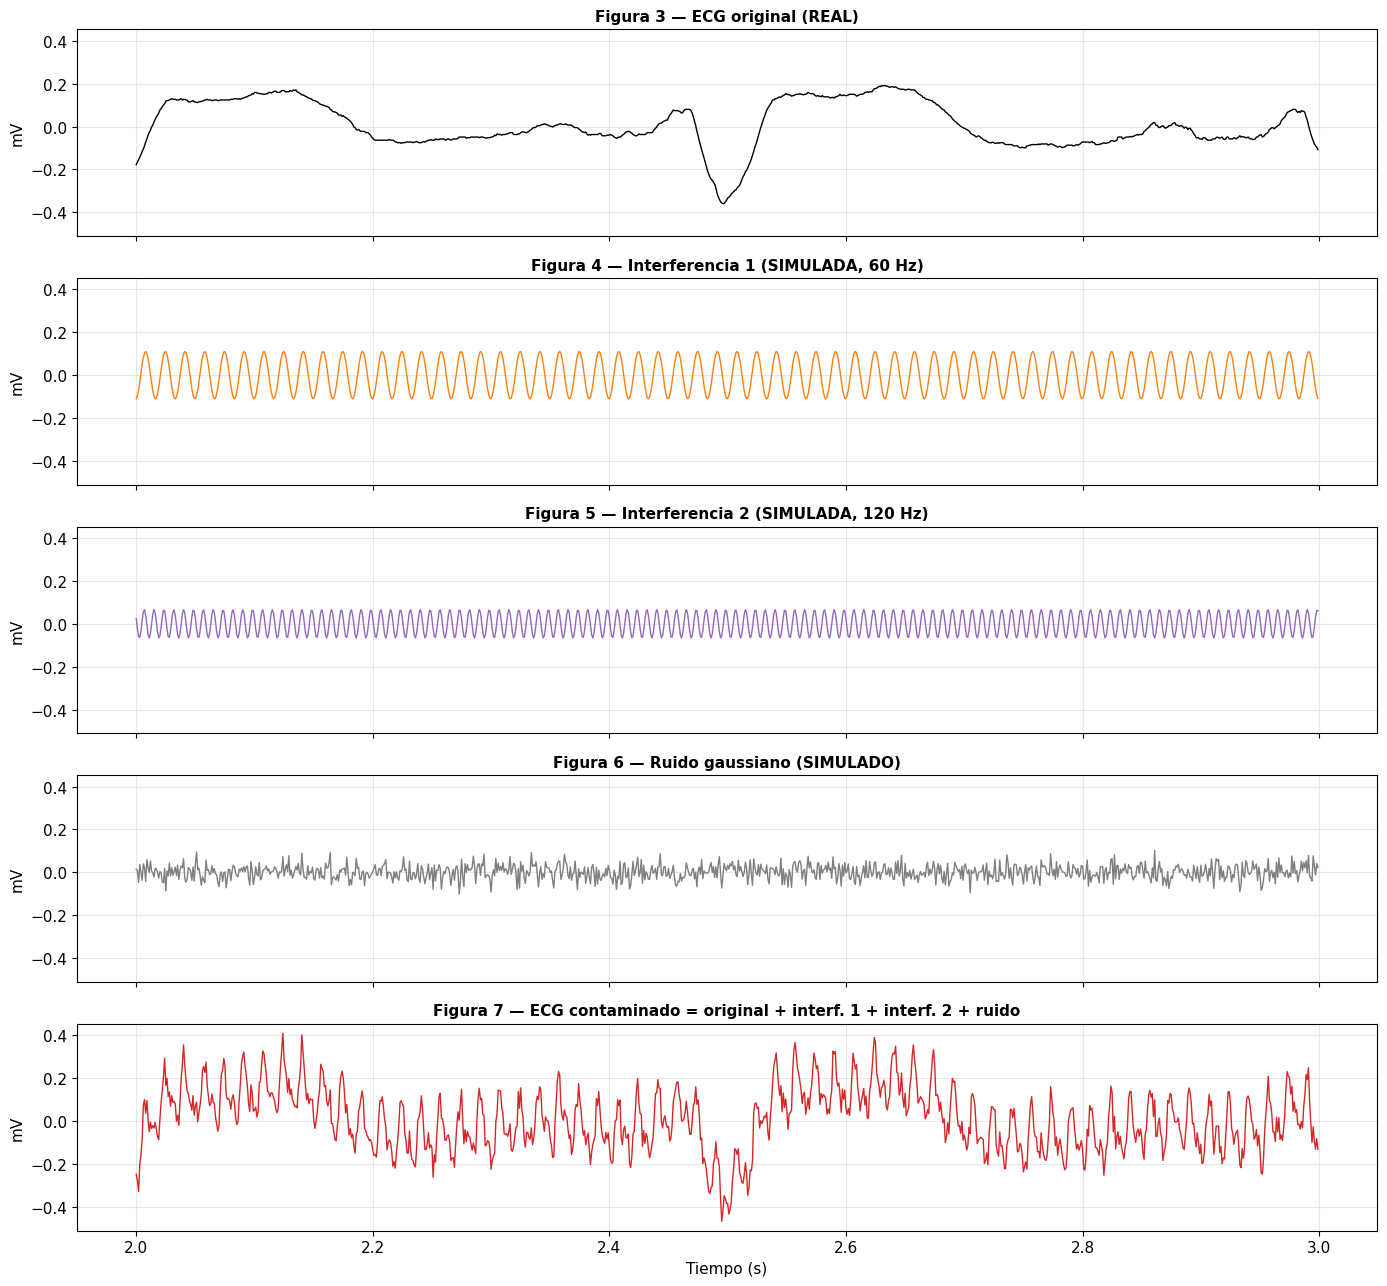

In [10]:
ventana_1s = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + 1.0)

componentes = [
    ("Figura 3 — ECG original (REAL)", ecg_original, "black"),
    (f"Figura 4 — Interferencia 1 (SIMULADA, {f1} Hz)", ruido_senoidal_1, "tab:orange"),
    (f"Figura 5 — Interferencia 2 (SIMULADA, {f2} Hz)", ruido_senoidal_2, "tab:purple"),
    ("Figura 6 — Ruido gaussiano (SIMULADO)", ruido_gaussiano, "tab:gray"),
    ("Figura 7 — ECG contaminado = original + interf. 1 + interf. 2 + ruido", ecg_contaminado, "tab:red"),
]

fig, ejes = plt.subplots(len(componentes), 1, figsize=(14, 13), sharex=True, sharey=True)
for eje, (titulo, senal, color) in zip(ejes, componentes):
    eje.plot(t[ventana_1s], senal[ventana_1s], color=color, lw=1)
    eje.set_title(titulo, fontsize=11)
    eje.set_ylabel("mV")
ejes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

```text
ECG original
        ↓
+ interferencias (f1, f2)
        ↓
+ ruido gaussiano
        ↓
ECG contaminado
```

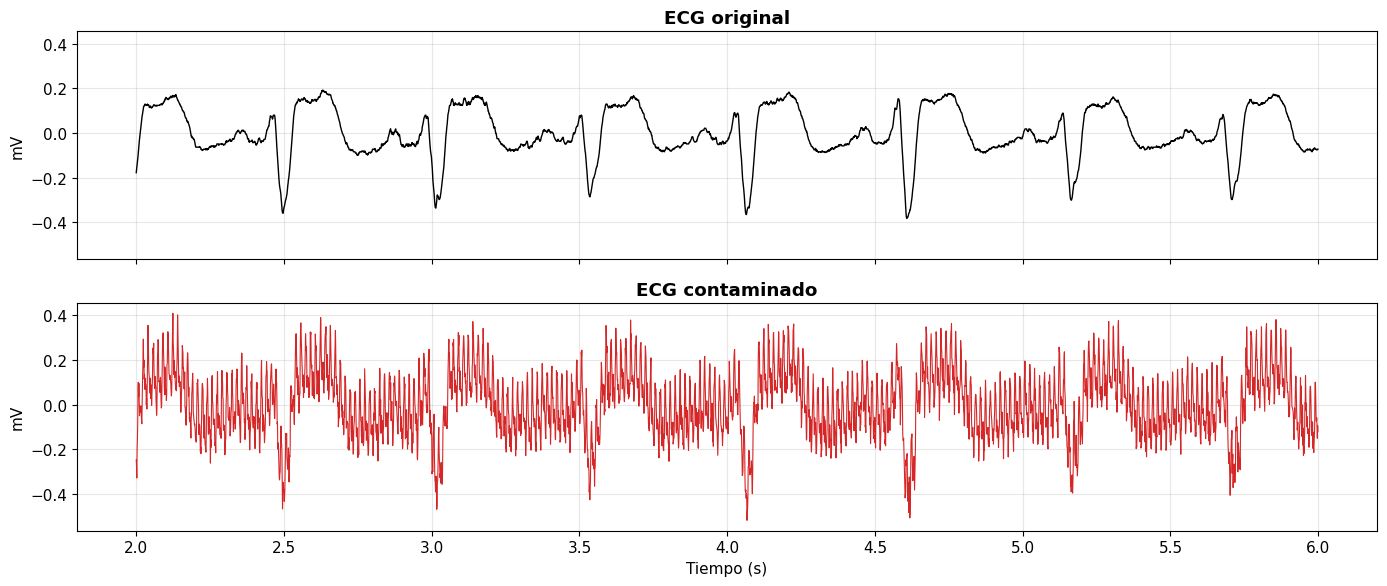

In [11]:
# Comparación directa en la ventana de 4 s
fig, ejes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
ejes[0].plot(t[zoom], ecg_original[zoom], color="black", lw=1)
ejes[0].set_title("ECG original")
ejes[1].plot(t[zoom], ecg_contaminado[zoom], color="tab:red", lw=0.8)
ejes[1].set_title("ECG contaminado")
for eje in ejes: eje.set_ylabel("mV")
ejes[1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

### 🔎 Observa y anota

- ¿Cambió la amplitud aparente de la señal?
- ¿Se conserva la forma de las ondas P y T?
- ¿Qué oscilaciones regulares aparecen?
- ¿Hay ruido de alta frecuencia?
- ¿Es más difícil identificar los complejos QRS?

✍️ **Respuesta:**

Al comparar ambas señales, se observó que la amplitud aparente aumentó después de agregar las interferencias y el ruido gaussiano. Los complejos QRS todavía se pueden reconocer, pero las ondas de menor amplitud, como P y T, se observan con menos claridad. También aparecen oscilaciones regulares producidas por las interferencias de 60 y 120 Hz. El ruido gaussiano hace que el trazo se vea más grueso e irregular, por lo que la identificación visual de los complejos QRS resulta un poco más difícil que en la señal original.


## 3.3 Análisis en el dominio de la frecuencia

> Una señal puede analizarse no solamente en función del tiempo, sino también en función de sus **componentes frecuenciales**.

```text
Dominio temporal
        ↕   Transformada de Fourier (FFT)
Dominio frecuencial
```

Intuitivamente, la FFT responde: *¿cuánto de cada frecuencia contiene la señal?* Una senoide pura de frecuencia $f_0$ aparece como **un pico estrecho** en $f_0$. El ruido gaussiano, en cambio, reparte su energía en **todas** las frecuencias (fondo plano).

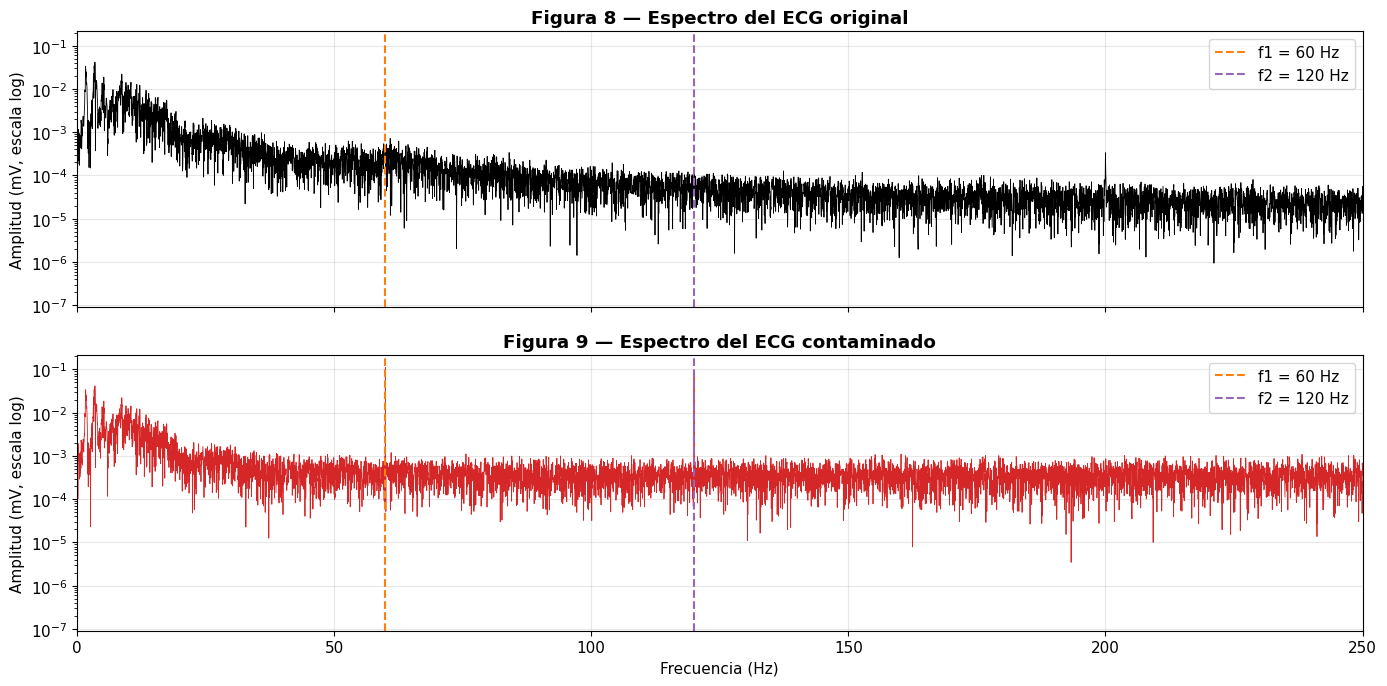

In [12]:
def espectro_amplitud(x, Fs):
    """Espectro de amplitud de un solo lado usando la FFT de NumPy."""
    N = len(x)
    X = np.fft.rfft(x - np.mean(x))
    frecuencias = np.fft.rfftfreq(N, d=1/Fs)
    amplitud = 2 * np.abs(X) / N
    return frecuencias[1:], amplitud[1:]   # omitimos 0 Hz (la media ya fue restada)

freq, amp_original = espectro_amplitud(ecg_original, Fs)
_,    amp_contaminado = espectro_amplitud(ecg_contaminado, Fs)

F_MAX_GRAFICO = min(250, Fs / 2)
fig, ejes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, sharey=True)
ejes[0].semilogy(freq, amp_original, color="black", lw=0.6)
ejes[0].set_title("Figura 8 — Espectro del ECG original")
ejes[1].semilogy(freq, amp_contaminado, color="tab:red", lw=0.6)
ejes[1].set_title("Figura 9 — Espectro del ECG contaminado")
for eje in ejes:
    eje.axvline(f1, color="tab:orange", ls="--", label=f"f1 = {f1} Hz")
    eje.axvline(f2, color="tab:purple", ls="--", label=f"f2 = {f2} Hz")
    eje.set_ylabel("Amplitud (mV, escala log)")
    eje.legend(loc="upper right")
ejes[1].set_xlabel("Frecuencia (Hz)")
ejes[1].set_xlim(0, F_MAX_GRAFICO)
plt.tight_layout(); plt.show()

### 🔎 Interpretación

- El ECG concentra la mayor parte de su energía en bajas frecuencias.
- En el espectro contaminado aparecen picos en 60 y 120 Hz, correspondientes a las interferencias agregadas.
- El ruido gaussiano eleva el fondo del espectro porque se distribuye en un rango amplio de frecuencias.

### ❓ Pregunta al estudiante

¿Por qué la interferencia aparece como un pico y el ruido gaussiano como un fondo? ¿Cuál de los dos será más fácil de eliminar con un filtro?

✍️ **Respuesta:**

La interferencia sinusoidal aparece como un pico porque se concentra en una frecuencia específica, en este caso 60 o 120 Hz. En cambio, el ruido gaussiano se distribuye en varias frecuencias y por eso se observa como un fondo más amplio. La interferencia sinusoidal es más sencilla de eliminar porque se conoce su frecuencia y se puede aplicar un filtro notch. El ruido gaussiano es más difícil de retirar sin modificar parte del ECG.


---
# 🟦 BLOQUE 4 — Aplicación de filtros digitales *(25 min)*

## 4.1 Tipos de filtros

| Filtro | Deja pasar | Uso típico en ECG |
|---|---|---|
| **Pasa-bajas** | Frecuencias por debajo de $f_c$ | Atenuar ruido de alta frecuencia (EMG, ruido electrónico). |
| **Pasa-altas** | Frecuencias por encima de $f_c$ | Eliminar la deriva de línea de base (respiración, movimiento). |
| **Pasa-banda** | Frecuencias entre $f_{c1}$ y $f_{c2}$ | Combinar ambos: típico 0.5 – 40 Hz para monitoreo. |
| **Notch (rechaza-banda)** | Todo excepto una banda muy estrecha | Eliminar una interferencia de frecuencia conocida (red eléctrica). |

**Herramientas de `scipy.signal`:**
- `butter`: diseña un filtro Butterworth (respuesta plana en la banda de paso).
- `iirnotch`: diseña un filtro notch centrado en una frecuencia.
- `filtfilt`: aplica el filtro hacia adelante y hacia atrás → **fase cero** (no desplaza los QRS en el tiempo).
- `freqz`: calcula la respuesta en frecuencia del filtro.

> 💡 Para el pasa-banda usamos la forma **SOS** (*second-order sections*) con `sosfiltfilt`, que es el equivalente numéricamente estable de `filtfilt` cuando la frecuencia de corte es muy baja respecto a $F_s$ (0.5 Hz frente a 1000 Hz).

In [13]:
def respuesta_sos(sos, Fs, n_puntos=16384):
    """Respuesta en frecuencia de un filtro en formato SOS (compatible con varias versiones de SciPy)."""
    funcion = getattr(signal, "freqz_sos", None) or signal.sosfreqz
    return funcion(sos, worN=n_puntos, fs=Fs)

def graficar_respuesta(w, h, titulo, marcas=()):
    plt.figure(figsize=(14, 3.5))
    plt.plot(w, 20 * np.log10(np.maximum(np.abs(h), 1e-10)), color="tab:blue")
    for f in marcas:
        plt.axvline(f, color="tab:red", ls="--", lw=1)
    plt.ylim(-80, 5); plt.xlim(0, F_MAX_GRAFICO)
    plt.title(titulo); plt.xlabel("Frecuencia (Hz)"); plt.ylabel("Ganancia (dB)")
    plt.show()

## 4.2 Experimento A — Filtro pasa-banda (Butterworth 0.5 – 40 Hz)

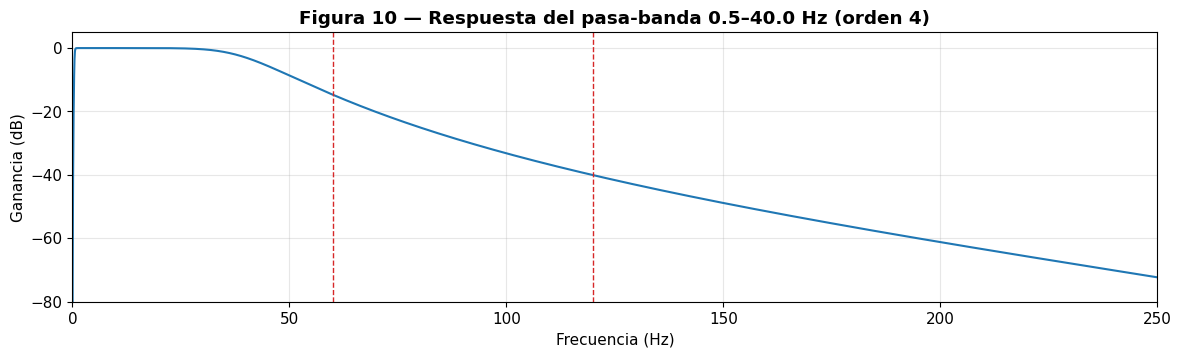

In [14]:
# =================== PARÁMETROS MODIFICABLES ===================
fc_baja = 0.5     # Hz
fc_alta = 40.0    # Hz
orden_pb = 4
# ===============================================================

sos_pasabanda = signal.butter(orden_pb, [fc_baja, fc_alta], btype="bandpass", fs=Fs, output="sos")
ecg_pasabanda = signal.sosfiltfilt(sos_pasabanda, ecg_contaminado)

w, h = respuesta_sos(sos_pasabanda, Fs)
graficar_respuesta(w, h, f"Figura 10 — Respuesta del pasa-banda {fc_baja}–{fc_alta} Hz (orden {orden_pb})", marcas=(f1, f2))

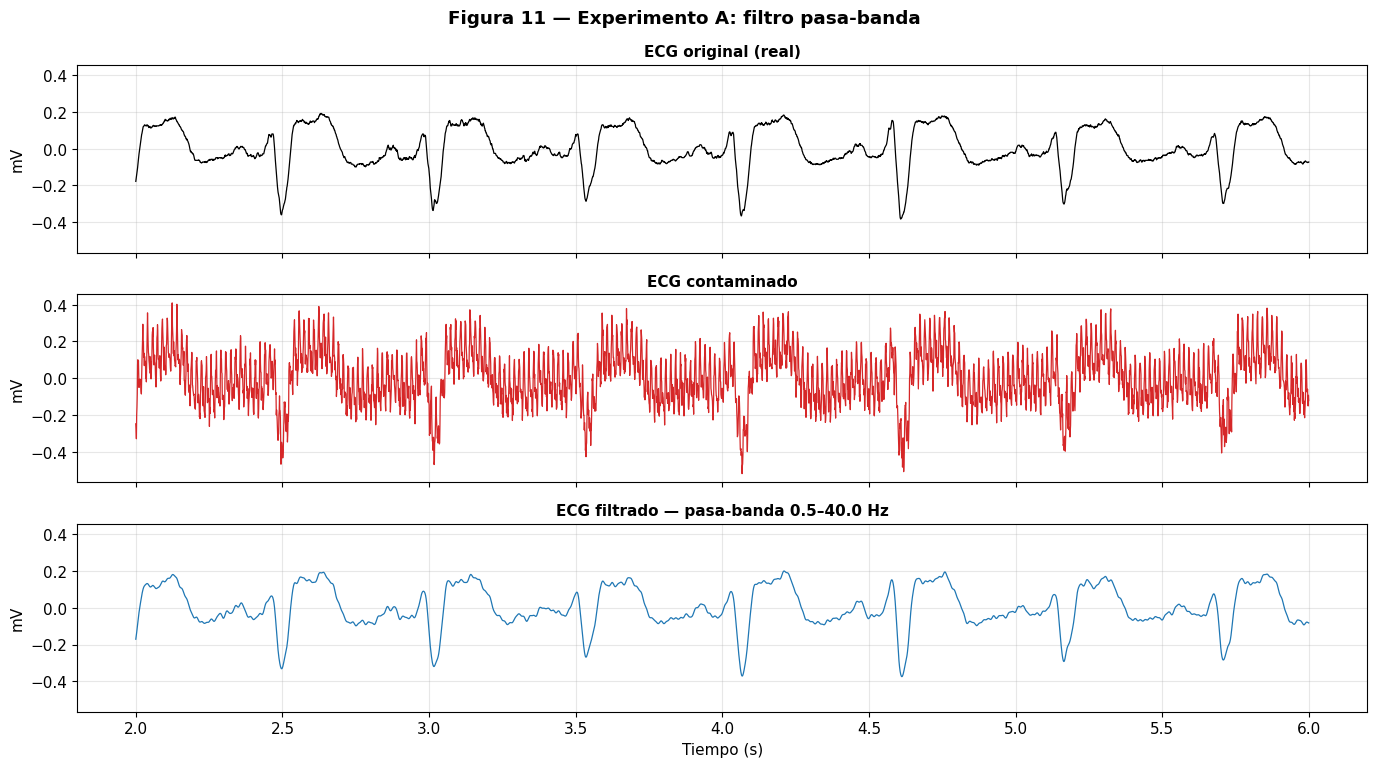

In [15]:
def comparar_senales(lista, titulo_general, mascara=zoom):
    """Grafica varias señales (titulo, señal, color) apiladas en la misma ventana temporal."""
    fig, ejes = plt.subplots(len(lista), 1, figsize=(14, 2.6 * len(lista)), sharex=True, sharey=True)
    for eje, (titulo, senal, color) in zip(ejes, lista):
        eje.plot(t[mascara], senal[mascara], color=color, lw=0.9)
        eje.set_title(titulo, fontsize=11); eje.set_ylabel("mV")
    ejes[-1].set_xlabel("Tiempo (s)")
    fig.suptitle(titulo_general, fontweight="bold")
    plt.tight_layout(); plt.show()

comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado — pasa-banda {fc_baja}–{fc_alta} Hz", ecg_pasabanda, "tab:blue"),
], "Figura 11 — Experimento A: filtro pasa-banda")

### 🔎 Interpretación — Experimento A
- **¿Qué se eliminó?** Ambas interferencias ($f_1$ y $f_2$ están fuera de la banda de paso) y la mayor parte del ruido gaussiano de alta frecuencia.
- **¿Qué permanece?** El ruido gaussiano que cae **dentro** de 0.5 – 40 Hz: ningún filtro lineal puede separarlo del ECG porque comparten frecuencias.
- **¿Qué se pudo afectar?** El pasa-banda también elimina contenido **real** del ECG: la deriva de línea de base (< 0.5 Hz) y parte del contenido de alta frecuencia del QRS (> 40 Hz). Observa si los picos R se ven un poco más bajos o redondeados.

## 4.3 Experimento B — Filtro notch

El notch elimina **una frecuencia concreta** y deja prácticamente intacto el resto del espectro. El **factor de calidad** $Q$ controla el ancho de la muesca: $\text{ancho} \approx f_0 / Q$.

**B1:** notch solo en $f_1$. **B2:** dos notch en cascada ($f_1$ y $f_2$).

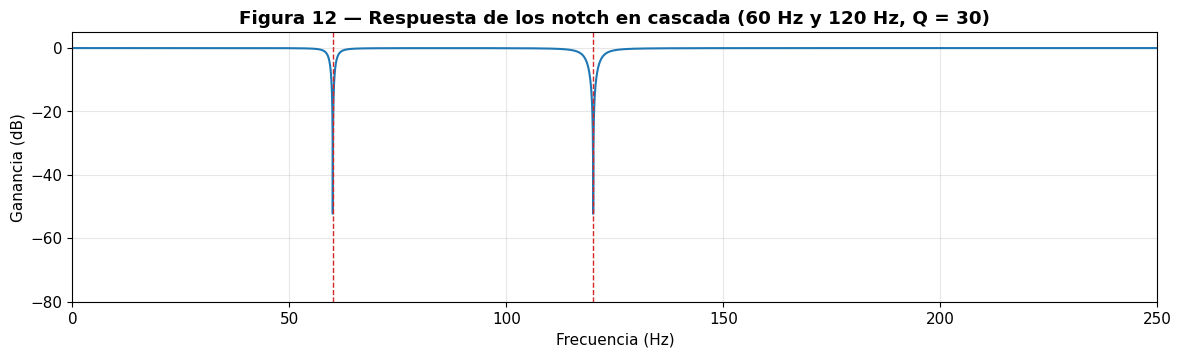

In [16]:
Q = 30   # factor de calidad (mayor Q → muesca más estrecha)

b_notch1, a_notch1 = signal.iirnotch(f1, Q, fs=Fs)
b_notch2, a_notch2 = signal.iirnotch(f2, Q, fs=Fs)

# B1: solo f1
ecg_notch_f1 = signal.filtfilt(b_notch1, a_notch1, ecg_contaminado)
# B2: f1 y luego f2 (cascada)
ecg_notch_f1f2 = signal.filtfilt(b_notch2, a_notch2, ecg_notch_f1)

# Respuesta en frecuencia de la cascada (producto de ambas respuestas)
w, h1 = signal.freqz(b_notch1, a_notch1, worN=16384, fs=Fs)
_, h2 = signal.freqz(b_notch2, a_notch2, worN=16384, fs=Fs)
graficar_respuesta(w, h1 * h2, f"Figura 12 — Respuesta de los notch en cascada ({f1} Hz y {f2} Hz, Q = {Q})", marcas=(f1, f2))

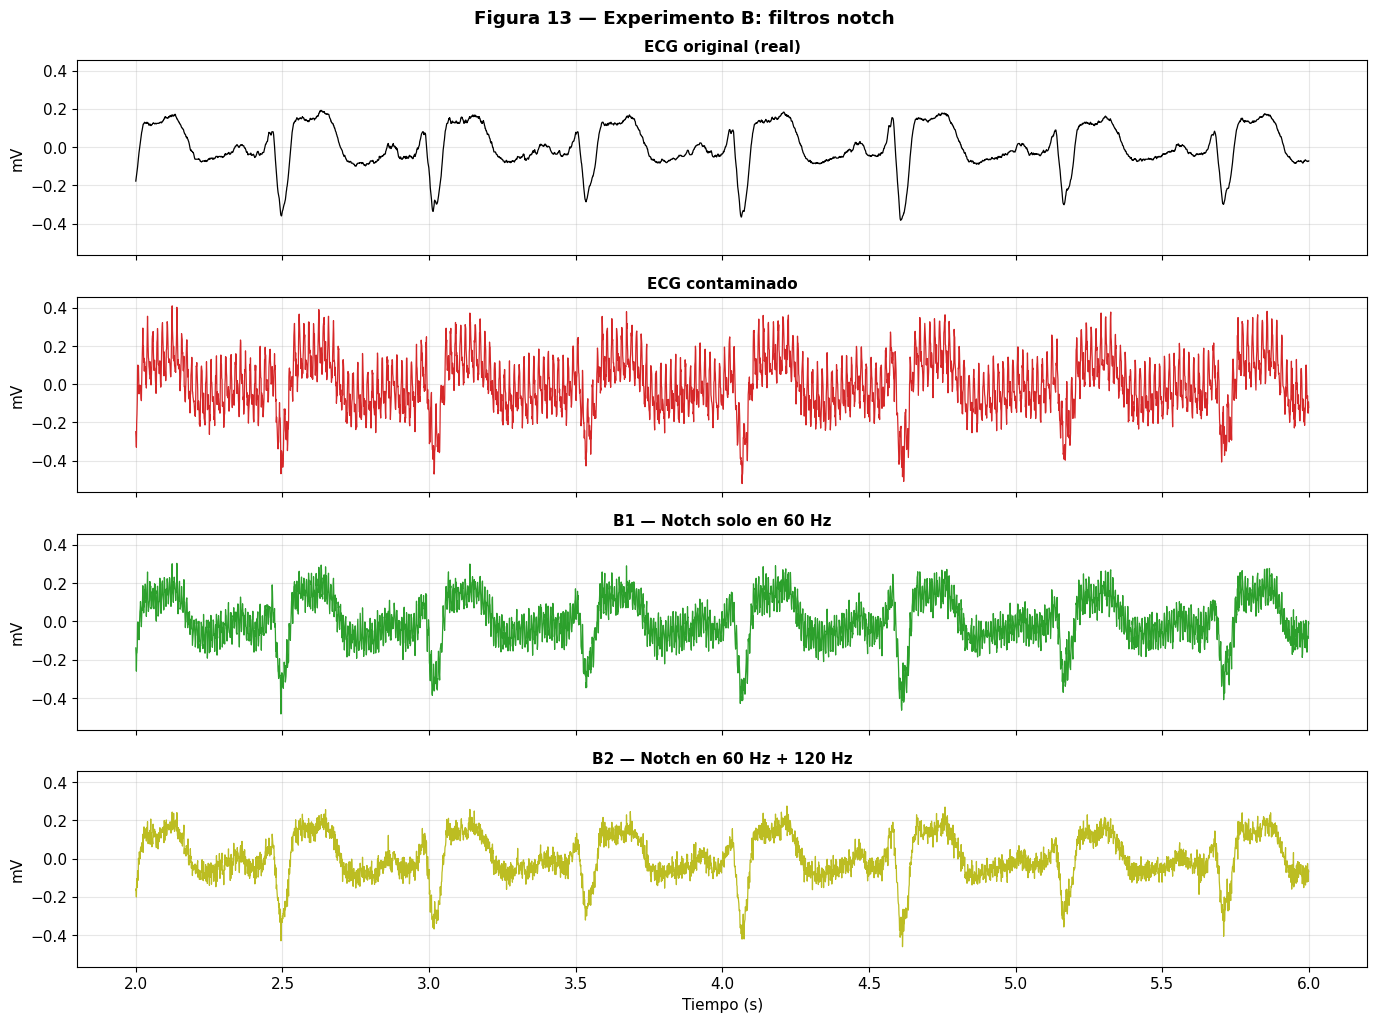

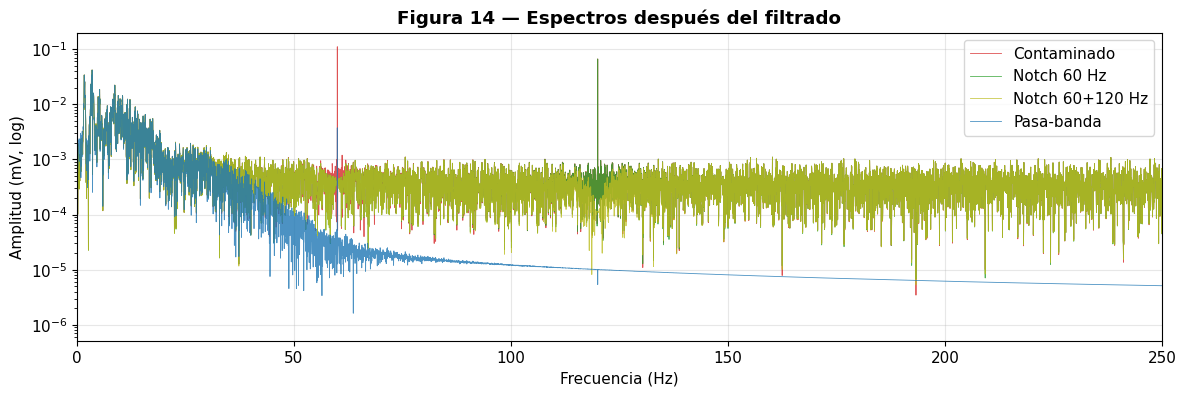

In [17]:
comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"B1 — Notch solo en {f1} Hz", ecg_notch_f1, "tab:green"),
    (f"B2 — Notch en {f1} Hz + {f2} Hz", ecg_notch_f1f2, "tab:olive"),
], "Figura 13 — Experimento B: filtros notch")

# Espectros después de cada filtrado
fig, eje = plt.subplots(figsize=(14, 4))
for etiqueta, senal, color in [("Contaminado", ecg_contaminado, "tab:red"),
                               (f"Notch {f1} Hz", ecg_notch_f1, "tab:green"),
                               (f"Notch {f1}+{f2} Hz", ecg_notch_f1f2, "tab:olive"),
                               ("Pasa-banda", ecg_pasabanda, "tab:blue")]:
    fr, am = espectro_amplitud(senal, Fs)
    eje.semilogy(fr, am, lw=0.6, label=etiqueta, color=color, alpha=0.8)
eje.set_xlim(0, F_MAX_GRAFICO); eje.legend()
eje.set_title("Figura 14 — Espectros después del filtrado")
eje.set_xlabel("Frecuencia (Hz)"); eje.set_ylabel("Amplitud (mV, log)")
plt.show()

In [18]:
# Comparación adicional solicitada: efecto del factor Q
resultados_Q = {}

def metricas_q(referencia, estimada):
    mascara_q = (t >= 2.0) & (t <= t[-1] - 2.0)
    x_q = referencia[mascara_q]
    y_q = estimada[mascara_q]
    error_q = y_q - x_q
    rmse_q = np.sqrt(np.mean(error_q**2))
    snr_q = 10 * np.log10(np.sum(x_q**2) / np.sum(error_q**2))
    correlacion_q = np.corrcoef(x_q, y_q)[0, 1]
    return {
        "RMSE (mV)": rmse_q,
        "SNR (dB)": snr_q,
        "Correlación r": correlacion_q,
    }

for Q_prueba in [5, 30, 100]:
    b_q1, a_q1 = signal.iirnotch(f1, Q_prueba, fs=Fs)
    b_q2, a_q2 = signal.iirnotch(f2, Q_prueba, fs=Fs)
    salida_q = signal.filtfilt(
        b_q2, a_q2,
        signal.filtfilt(b_q1, a_q1, ecg_contaminado)
    )
    resultados_Q[f"Q = {Q_prueba}"] = metricas_q(ecg_original, salida_q)

pd.DataFrame(resultados_Q).T.round(4)


,RMSE (mV),SNR (dB),Correlación r
Q = 5,0.0308,11.1556,0.9638
Q = 30,0.0328,10.5919,0.9592
Q = 100,0.0331,10.5125,0.9585


### 🔎 Interpretación — Experimento B

- El primer notch elimina el pico de 60 Hz, pero mantiene la interferencia de 120 Hz.
- Al colocar ambos filtros en cascada se reducen los dos picos.
- El ruido gaussiano permanece porque el notch solamente actúa alrededor de las frecuencias indicadas.

### ❓ Pregunta al estudiante

Cambia `Q` a 5 y luego a 100. ¿Qué ocurre con el ancho de la muesca y con la señal filtrada?

✍️ **Respuesta:**

Con `Q = 5`, la muesca es más ancha y se obtuvo una SNR de 11,1556 dB. Con `Q = 100`, la muesca fue más estrecha y la SNR fue de 10,5125 dB. El valor intermedio `Q = 30` alcanzó 10,5919 dB. En este registro, `Q = 5` redujo ligeramente más la contaminación, aunque una muesca más ancha también puede retirar componentes cercanos del ECG.

## 4.4 Comparación cuantitativa

Las métricas **complementan** (no reemplazan) la evaluación visual:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{N}\sum (x - \hat{x})^2}$ | Error promedio (mV). **Menor es mejor.** |
| **SNR** | $10\log_{10}\frac{\sum x^2}{\sum (x-\hat{x})^2}$ | Relación señal/error en dB. **Mayor es mejor.** |
| **Correlación** $r$ | coeficiente de Pearson | Similitud de forma (1 = idéntica). |

donde $x$ es el ECG original y $\hat{x}$ la señal evaluada. Excluimos los primeros y últimos 2 s para evitar efectos de borde (y el tiempo de convergencia del filtro adaptativo que veremos luego).

In [19]:
MARGEN_S = 2.0
evaluacion = (t >= MARGEN_S) & (t <= t[-1] - MARGEN_S)

def calcular_metricas(referencia, estimada, mascara=evaluacion):
    x, y = referencia[mascara], estimada[mascara]
    error = y - x
    rmse = np.sqrt(np.mean(error ** 2))
    snr = 10 * np.log10(np.sum(x ** 2) / np.sum(error ** 2))
    r = np.corrcoef(x, y)[0, 1]
    return {"RMSE (mV)": rmse, "SNR (dB)": snr, "Correlación r": r}

resultados = {
    "Contaminado (sin filtrar)": calcular_metricas(ecg_original, ecg_contaminado),
    "A — Pasa-banda": calcular_metricas(ecg_original, ecg_pasabanda),
    f"B1 — Notch {f1} Hz": calcular_metricas(ecg_original, ecg_notch_f1),
    f"B2 — Notch {f1}+{f2} Hz": calcular_metricas(ecg_original, ecg_notch_f1f2),
}
pd.DataFrame(resultados).T.round(4)

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.0968,1.2002,0.7546
A — Pasa-banda,0.0107,20.2939,0.9954
B1 — Notch 60 Hz,0.0573,5.7569,0.8893
B2 — Notch 60+120 Hz,0.0328,10.5919,0.9592


### ¿Cuánto modifica el filtro a la propia señal original?

Un detalle importante: el pasa-banda **también** cambia el ECG original (quita su deriva de base y su contenido > 40 Hz). Para separar "ruido no eliminado" de "distorsión del filtro", filtramos el **original limpio** y lo comparamos consigo mismo.

In [20]:
ecg_original_pasabanda = signal.sosfiltfilt(sos_pasabanda, ecg_original)
ecg_original_notch = signal.filtfilt(b_notch2, a_notch2, signal.filtfilt(b_notch1, a_notch1, ecg_original))

pd.DataFrame({
    "Pasa-banda aplicado al ORIGINAL": calcular_metricas(ecg_original, ecg_original_pasabanda),
    "Notch f1+f2 aplicado al ORIGINAL": calcular_metricas(ecg_original, ecg_original_notch),
}).T.round(4)

,RMSE (mV),SNR (dB),Correlación r
Pasa-banda aplicado al ORIGINAL,0.0057,25.8732,0.9987
Notch f1+f2 aplicado al ORIGINAL,0.0014,38.0287,0.9999


### 🔎 Interpretación

El filtro pasa-banda redujo la contaminación con una modificación pequeña de la señal original. Los filtros notch alteraron menos la morfología porque actuaron solamente alrededor de 60 y 120 Hz.

### ❓ Pregunta al estudiante

¿Qué filtro obtuvo mejor SNR? ¿Coincide con lo que observaste visualmente?

✍️ **Respuesta:**

El filtro pasa-banda obtuvo la mejor SNR, con 20,2939 dB, y una correlación de 0,9954. El notch doble alcanzó una SNR de 10,5919 dB. Esto coincide con las gráficas porque el pasa-banda redujo las interferencias y parte del ruido de alta frecuencia. Sin embargo, el notch conservó mejor la forma original al eliminar únicamente bandas estrechas.

---
# 🟦 BLOQUE 5 — Filtros adaptativos y Transformada Wavelet *(20 min)*

## 5.1 ¿Qué es un filtro adaptativo?

Un filtro **convencional** tiene coeficientes **fijos**: se diseña una vez y se aplica igual a toda la señal. Un filtro **adaptativo** **modifica sus coeficientes muestra a muestra** en función de la información que recibe, por lo que puede seguir interferencias cuya amplitud o fase cambian en el tiempo.

```text
Señal contaminada d[n] ──────────────────────────►(+)──► e[n] = ECG estimado
                                                    ▲(−)
                                                    │
señal de referencia x[n] ──► Filtro adaptativo ──► y[n] = interferencia estimada
                                  ▲
                                  └──── se ajusta usando el error e[n]
```

| Concepto | Significado en este laboratorio |
|---|---|
| **Señal de referencia** $x[n]$ | Señal **correlacionada con la interferencia** pero no con el ECG (aquí: senos y cosenos de $f_1$ y $f_2$). En la práctica puede provenir de un sensor que capta la red eléctrica. |
| **Coeficientes** $w$ | Pesos que el filtro ajusta para "imitar" la interferencia. |
| **Salida** $y[n] = w^T x[n]$ | Estimación de la interferencia. |
| **Error** $e[n] = d[n] - y[n]$ | Lo que queda al restar la interferencia estimada: **es nuestro ECG limpio**. |
| **Adaptación (LMS)** | $w[n+1] = w[n] + 2\mu\, e[n]\, x[n]$ |
| **Paso** $\mu$ | Velocidad de aprendizaje: grande → rápido pero inestable/distorsionante; pequeño → lento pero preciso. |

El algoritmo **LMS** (*Least Mean Squares*) minimiza poco a poco la potencia del error. Como el ECG no está correlacionado con la referencia, la única forma de reducir el error es **cancelar la interferencia**.

In [21]:
def filtro_lms(senal_contaminada, referencias, mu):
    """
    Cancelador adaptativo de interferencias con algoritmo LMS (versión didáctica).
    senal_contaminada : vector d[n] de tamaño N
    referencias       : matriz N x M (cada columna es una señal de referencia)
    mu                : paso de adaptación
    Devuelve: e (señal limpia estimada), y (interferencia estimada), historial de pesos
    """
    N, M = referencias.shape
    w = np.zeros(M)                       # los coeficientes empiezan en cero: el filtro "no sabe nada"
    y = np.zeros(N)
    e = np.zeros(N)
    historial_w = np.zeros((N, M))
    for n in range(N):
        x_n = referencias[n]              # vector de referencia en el instante n
        y[n] = w @ x_n                    # 1) estimar la interferencia
        e[n] = senal_contaminada[n] - y[n]  # 2) calcular el error (ECG estimado)
        w = w + 2 * mu * e[n] * x_n       # 3) actualizar los coeficientes (LMS)
        historial_w[n] = w
    return e, y, historial_w

# Referencias: seno y coseno de cada frecuencia (permiten ajustar amplitud Y fase)
referencias = np.column_stack([
    np.sin(2 * np.pi * f1 * t), np.cos(2 * np.pi * f1 * t),
    np.sin(2 * np.pi * f2 * t), np.cos(2 * np.pi * f2 * t),
])

MU = 0.005   # =================== PARÁMETRO MODIFICABLE ===================
ecg_lms, interferencia_estimada, pesos = filtro_lms(ecg_contaminado, referencias, MU)
print("Filtrado adaptativo completado.")

Filtrado adaptativo completado.


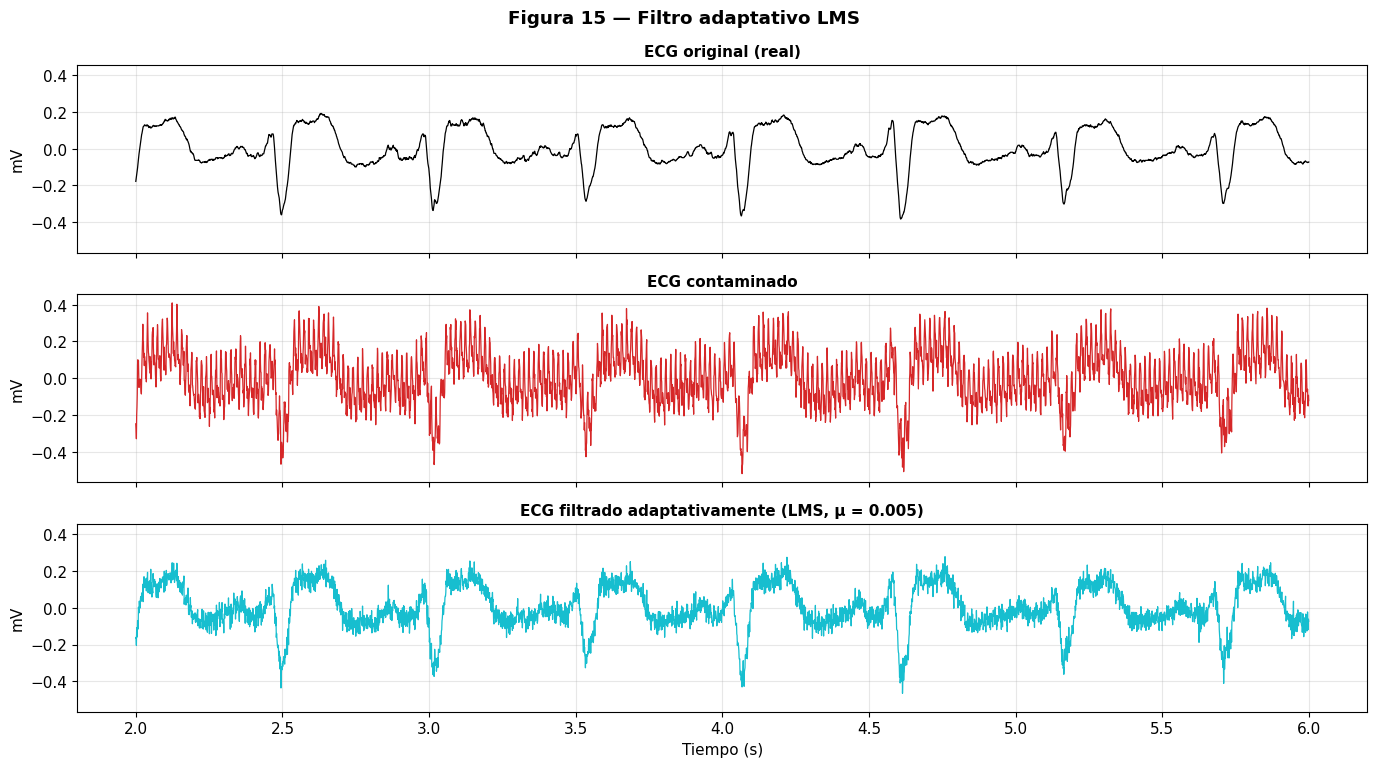

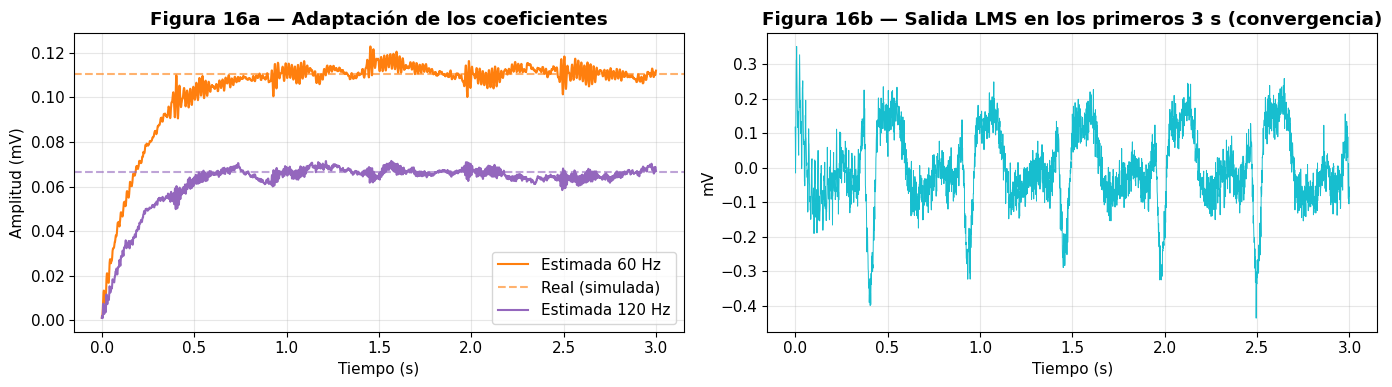

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.0968,1.2002,0.7546
A — Pasa-banda,0.0107,20.2939,0.9954
B1 — Notch 60 Hz,0.0573,5.7569,0.8893
B2 — Notch 60+120 Hz,0.0328,10.5919,0.9592
LMS adaptativo,0.0335,10.4155,0.9585


In [22]:
comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado adaptativamente (LMS, μ = {MU})", ecg_lms, "tab:cyan"),
], "Figura 15 — Filtro adaptativo LMS")

# ¿Cómo "aprende" el filtro? Amplitud estimada de cada interferencia en el tiempo
amplitud_est_1 = np.hypot(pesos[:, 0], pesos[:, 1])
amplitud_est_2 = np.hypot(pesos[:, 2], pesos[:, 3])
primeros = t < 3.0

fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
ejes[0].plot(t[primeros], amplitud_est_1[primeros], label=f"Estimada {f1} Hz", color="tab:orange")
ejes[0].axhline(amplitud_1, ls="--", color="tab:orange", alpha=0.6, label="Real (simulada)")
ejes[0].plot(t[primeros], amplitud_est_2[primeros], label=f"Estimada {f2} Hz", color="tab:purple")
ejes[0].axhline(amplitud_2, ls="--", color="tab:purple", alpha=0.6)
ejes[0].set_title("Figura 16a — Adaptación de los coeficientes")
ejes[0].set_xlabel("Tiempo (s)"); ejes[0].set_ylabel("Amplitud (mV)"); ejes[0].legend()

ejes[1].plot(t[primeros], ecg_lms[primeros], color="tab:cyan", lw=0.7)
ejes[1].set_title("Figura 16b — Salida LMS en los primeros 3 s (convergencia)")
ejes[1].set_xlabel("Tiempo (s)"); ejes[1].set_ylabel("mV")
plt.tight_layout(); plt.show()

resultados["LMS adaptativo"] = calcular_metricas(ecg_original, ecg_lms)
pd.DataFrame(resultados).T.round(4)

In [23]:
# Comparación adicional solicitada: efecto del paso de adaptación MU
resultados_MU = {}

for mu_prueba in [0.0005, 0.005, 0.05]:
    salida_mu, _, _ = filtro_lms(ecg_contaminado, referencias, mu_prueba)
    resultados_MU[f"MU = {mu_prueba}"] = calcular_metricas(ecg_original, salida_mu)

pd.DataFrame(resultados_MU).T.round(4)


,RMSE (mV),SNR (dB),Correlación r
MU = 0.0005,0.0340,10.2987,0.9566
MU = 0.005,0.0335,10.4155,0.9585
MU = 0.05,0.0378,9.3555,0.9602


### 🔎 Interpretación — Filtro adaptativo

- Al inicio los coeficientes son cero y el filtro todavía no ha estimado las interferencias.
- Durante las primeras muestras, el algoritmo adapta sus coeficientes hasta aproximarse a las componentes de 60 y 120 Hz.
- El ruido gaussiano permanece porque no está relacionado con las referencias utilizadas.

### ❓ Pregunta al estudiante

Cambia `MU` a 0.0005 y a 0.05. ¿Qué pasa con la velocidad de convergencia y con la calidad de la señal?

✍️ **Respuesta:**

Con `MU = 0.0005`, la adaptación fue más lenta y se obtuvo una SNR de 10,2987 dB. Con `MU = 0.05`, la adaptación fue más rápida, pero la SNR disminuyó a 9,3555 dB. El valor `MU = 0.005` presentó un resultado más equilibrado, con una SNR de 10,4155 dB. Por ello, un valor muy pequeño demora la convergencia, mientras que uno muy grande puede disminuir la estabilidad.

## 5.2 Transformada Wavelet

> ### ¿Para qué sirve la Transformada Wavelet en el procesamiento de señales biomédicas?

La FFT nos dice **qué frecuencias** hay en la señal, pero **no cuándo** aparecen (analiza la señal completa de forma global). La **Transformada Wavelet** descompone la señal usando pequeñas "ondas" (*wavelets*) de duración limitada, a distintas **escalas**:

- **Escalas pequeñas** → detalles rápidos (alta frecuencia), bien localizados en el tiempo.
- **Escalas grandes** → tendencias lentas (baja frecuencia).

Esto encaja muy bien con el ECG:
- el **complejo QRS** es un evento rápido y localizado;
- las ondas **P** y **T** son más lentas;
- el **ruido** suele dispersarse en los detalles finos con coeficientes pequeños;
- la **deriva de base** vive en la aproximación más gruesa.

### Descomposición Wavelet Discreta (DWT)

En cada nivel la señal se divide en una **aproximación** (A, parte lenta) y un **detalle** (D, parte rápida); la aproximación se vuelve a dividir:

```text
Señal ─┬─► D1 (Fs/4 – Fs/2)
       └─► A1 ─┬─► D2 (Fs/8 – Fs/4)
               └─► A2 ─┬─► D3 ...
                       └─► ... ─► A_L (la parte más lenta)
```

Usaremos la wavelet **Daubechies 4 (`db4`)**, muy empleada en ECG porque su forma se parece a la de un complejo QRS.

In [24]:
WAVELET = "db4"
nivel_max = pywt.dwt_max_level(len(ecg_original), pywt.Wavelet(WAVELET).dec_len)
NIVEL = min(8, nivel_max)

# Banda de frecuencias aproximada de cada nivel
print(f"Wavelet: {WAVELET} | Niveles: {NIVEL}\n")
print(f"A{NIVEL}: 0 – {Fs / 2**(NIVEL+1):.1f} Hz (aproximación)")
for j in range(NIVEL, 0, -1):
    print(f"D{j}: {Fs / 2**(j+1):.1f} – {Fs / 2**j:.1f} Hz")
print(f"\nInterferencia 1 ({f1} Hz) y 2 ({f2} Hz): ubícalas en la tabla anterior.")

def componentes_por_nivel(x, wavelet, nivel):
    """Reconstruye por separado la contribución de la aproximación y de cada detalle (en el dominio del tiempo)."""
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    componentes = {}
    nombres = [f"A{nivel}"] + [f"D{j}" for j in range(nivel, 0, -1)]
    for i, nombre in enumerate(nombres):
        coefs_solo = [c if k == i else np.zeros_like(c) for k, c in enumerate(coefs)]
        componentes[nombre] = pywt.waverec(coefs_solo, wavelet)[:len(x)]
    return componentes

comp_original = componentes_por_nivel(ecg_original, WAVELET, NIVEL)
comp_contaminado = componentes_por_nivel(ecg_contaminado, WAVELET, NIVEL)

Wavelet: db4 | Niveles: 8

A8: 0 – 2.0 Hz (aproximación)
D8: 2.0 – 3.9 Hz
D7: 3.9 – 7.8 Hz
D6: 7.8 – 15.6 Hz
D5: 15.6 – 31.2 Hz
D4: 31.2 – 62.5 Hz
D3: 62.5 – 125.0 Hz
D2: 125.0 – 250.0 Hz
D1: 250.0 – 500.0 Hz

Interferencia 1 (60 Hz) y 2 (120 Hz): ubícalas en la tabla anterior.


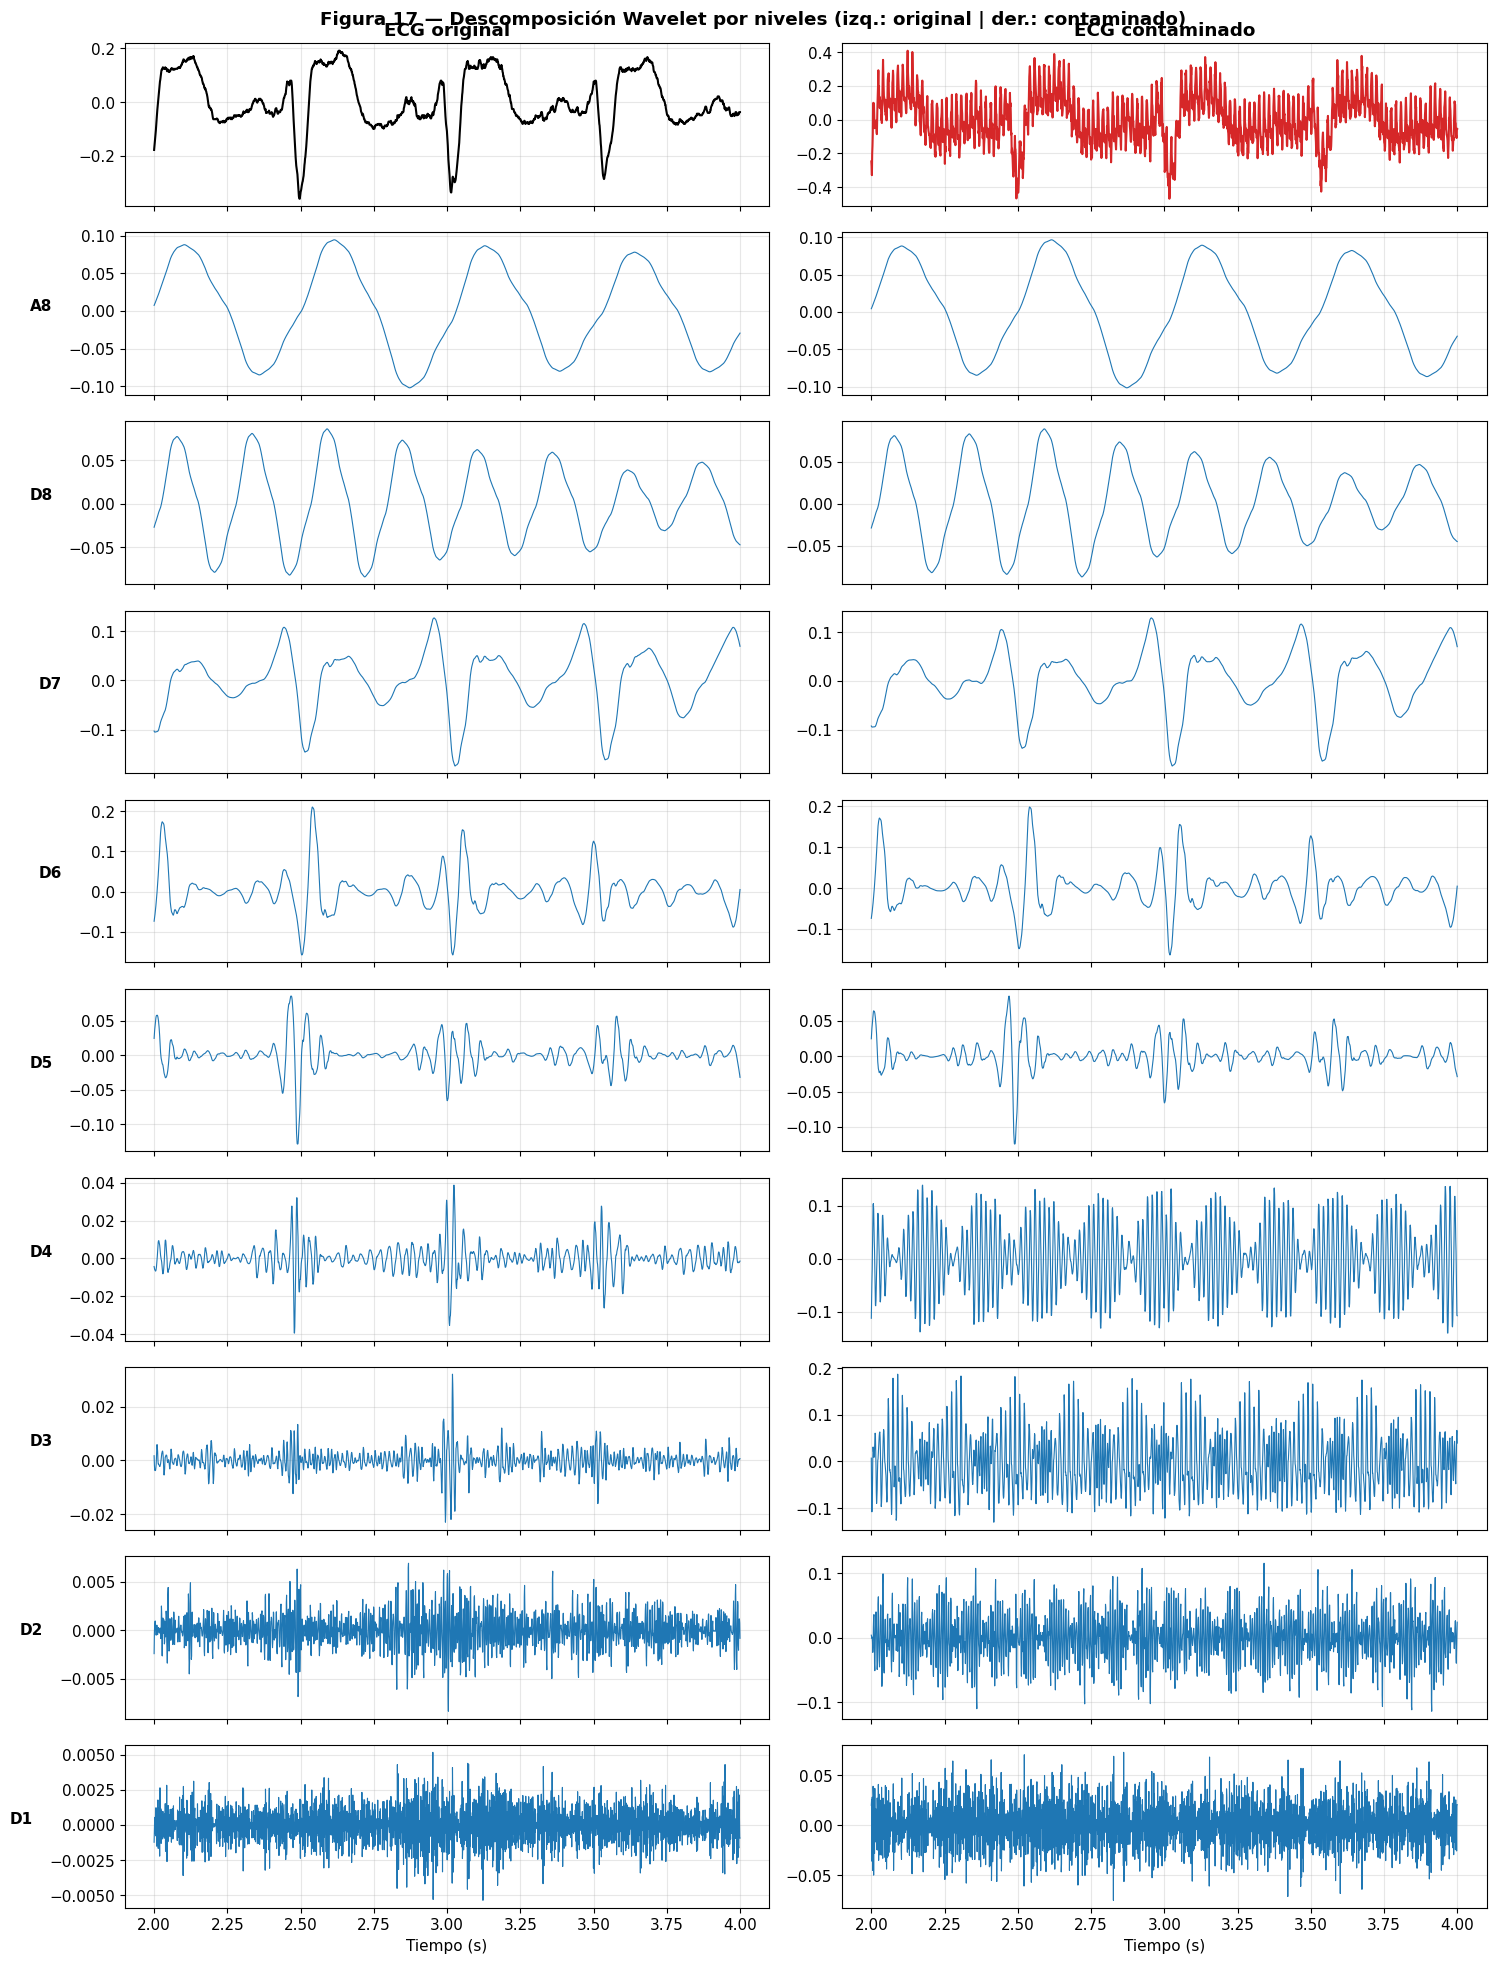

In [25]:
ventana_2s = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + 2.0)
nombres = list(comp_original.keys())

fig, ejes = plt.subplots(len(nombres) + 1, 2, figsize=(15, 2 * (len(nombres) + 1)), sharex=True)
ejes[0, 0].plot(t[ventana_2s], ecg_original[ventana_2s], color="black"); ejes[0, 0].set_title("ECG original")
ejes[0, 1].plot(t[ventana_2s], ecg_contaminado[ventana_2s], color="tab:red"); ejes[0, 1].set_title("ECG contaminado")
for i, nombre in enumerate(nombres, start=1):
    ejes[i, 0].plot(t[ventana_2s], comp_original[nombre][ventana_2s], color="tab:blue", lw=0.8)
    ejes[i, 1].plot(t[ventana_2s], comp_contaminado[nombre][ventana_2s], color="tab:blue", lw=0.8)
    ejes[i, 0].set_ylabel(nombre, rotation=0, labelpad=20, fontweight="bold")
ejes[-1, 0].set_xlabel("Tiempo (s)"); ejes[-1, 1].set_xlabel("Tiempo (s)")
fig.suptitle("Figura 17 — Descomposición Wavelet por niveles (izq.: original | der.: contaminado)", fontweight="bold")
plt.tight_layout(); plt.show()

### 🔎 Interpretación — Descomposición
- **D1, D2** (frecuencias altas): en el original casi no hay energía; en el contaminado aparecen dominados por **ruido gaussiano**.
- **D3, D4**: aquí "caen" las interferencias de 120 Hz y 60 Hz (oscilaciones regulares).
- **D5 – D7**: contienen la energía de los **complejos QRS** (picos localizados en el tiempo).
- **A8 (aproximación)**: tendencia lenta y **deriva de línea de base**.
- Observa que en los detalles el QRS aparece **localizado en el tiempo**: eso es lo que la FFT global no puede mostrar.

## 5.3 *Denoising* mediante Wavelet (umbralización)

Idea: los eventos importantes (QRS) producen **pocos coeficientes grandes**; el ruido produce **muchos coeficientes pequeños**. Entonces:

1. Descomponer la señal (DWT).
2. Estimar el nivel de ruido con el detalle más fino: $\sigma = \text{mediana}(|D_1|)/0.6745$.
3. Calcular un umbral (universal): $\lambda = \sigma\sqrt{2\ln N}$.
4. **Umbralizar** los detalles: los coeficientes con $|c| < \lambda$ se anulan, los demás se reducen (*soft thresholding*).
5. Reconstruir la señal (IDWT).

Umbral universal aplicado: 0.1509


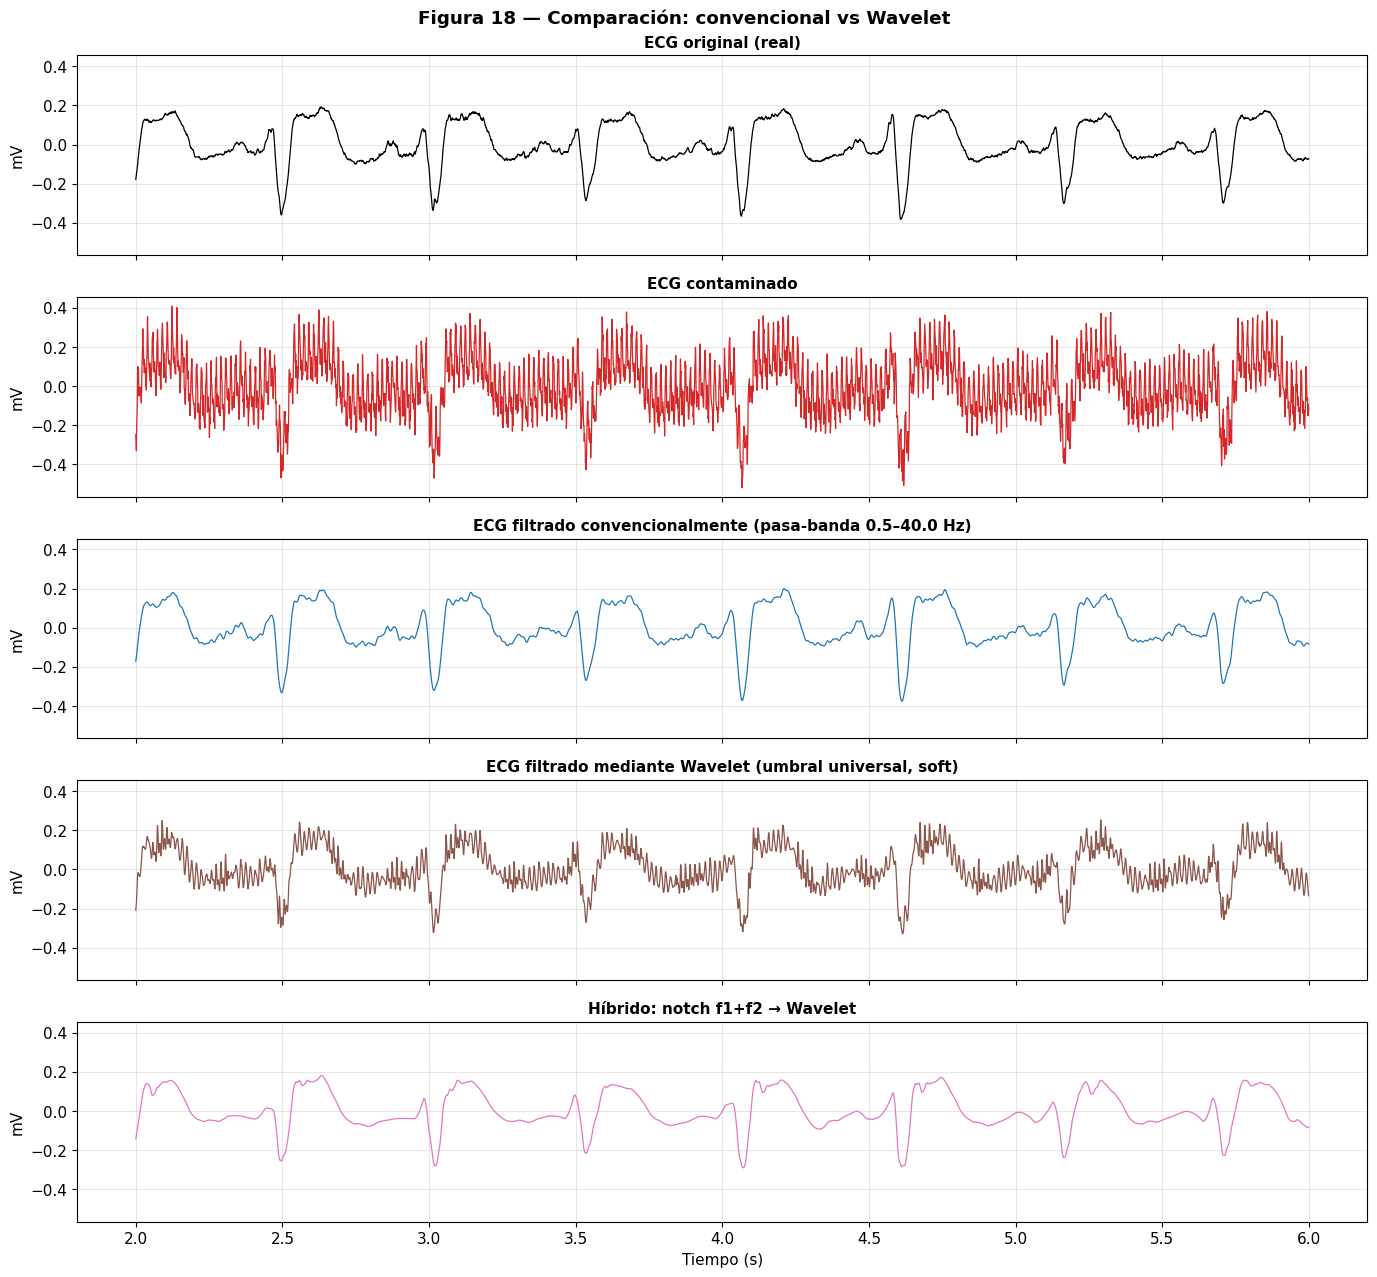

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.0968,1.2002,0.7546
A — Pasa-banda,0.0107,20.2939,0.9954
B1 — Notch 60 Hz,0.0573,5.7569,0.8893
B2 — Notch 60+120 Hz,0.0328,10.5919,0.9592
LMS adaptativo,0.0335,10.4155,0.9585
Wavelet (denoising),0.0460,7.6667,0.9104
Híbrido notch + Wavelet,0.0267,12.3747,0.9789


In [26]:
def denoising_wavelet(x, wavelet=WAVELET, nivel=NIVEL, modo="soft"):
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    sigma = np.median(np.abs(coefs[-1])) / 0.6745            # ruido estimado a partir de D1
    umbral = sigma * np.sqrt(2 * np.log(len(x)))              # umbral universal
    coefs_umbral = [coefs[0]] + [pywt.threshold(c, umbral, mode=modo) for c in coefs[1:]]
    x_limpia = pywt.waverec(coefs_umbral, wavelet)[:len(x)]
    return x_limpia, umbral

# 1) Wavelet aplicada directamente a la señal contaminada
ecg_wavelet, umbral = denoising_wavelet(ecg_contaminado)
# 2) Enfoque híbrido: primero notch (quita interferencias), luego wavelet (quita ruido gaussiano)
ecg_hibrido, _ = denoising_wavelet(ecg_notch_f1f2)

print(f"Umbral universal aplicado: {umbral:.4f}")

comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado convencionalmente (pasa-banda {fc_baja}–{fc_alta} Hz)", ecg_pasabanda, "tab:blue"),
    ("ECG filtrado mediante Wavelet (umbral universal, soft)", ecg_wavelet, "tab:brown"),
    ("Híbrido: notch f1+f2 → Wavelet", ecg_hibrido, "tab:pink"),
], "Figura 18 — Comparación: convencional vs Wavelet")

resultados["Wavelet (denoising)"] = calcular_metricas(ecg_original, ecg_wavelet)
resultados["Híbrido notch + Wavelet"] = calcular_metricas(ecg_original, ecg_hibrido)
pd.DataFrame(resultados).T.round(4)

In [27]:
# Comparación adicional solicitada: wavelet y tipo de umbralización
resultados_wavelet = {}

for wavelet_prueba in ["db4", "sym8"]:
    for modo_prueba in ["soft", "hard"]:
        nivel_prueba = min(
            8,
            pywt.dwt_max_level(
                len(ecg_original),
                pywt.Wavelet(wavelet_prueba).dec_len
            )
        )
        salida_wavelet, _ = denoising_wavelet(
            ecg_contaminado,
            wavelet=wavelet_prueba,
            nivel=nivel_prueba,
            modo=modo_prueba
        )
        nombre = f"{wavelet_prueba} - {modo_prueba}"
        resultados_wavelet[nombre] = calcular_metricas(ecg_original, salida_wavelet)

pd.DataFrame(resultados_wavelet).T.round(4)


,RMSE (mV),SNR (dB),Correlación r
db4 - soft,0.0460,7.6667,0.9104
db4 - hard,0.0832,2.5117,0.7978
sym8 - soft,0.0468,7.5054,0.9071
sym8 - hard,0.0847,2.3554,0.7930


### 🔎 Interpretación — *Denoising* Wavelet

- La umbralización reduce parte del ruido gaussiano y conserva los componentes más grandes de la señal.
- Las interferencias sinusoidales pueden permanecer porque producen coeficientes grandes en algunos niveles.
- El método híbrido combina el notch para retirar las interferencias y Wavelet para reducir el ruido restante.

### ❓ Pregunta al estudiante

Cambia `modo="soft"` por `modo="hard"` y prueba la wavelet `"sym8"` en lugar de `"db4"`. ¿Cómo cambian la forma del QRS y las métricas?

✍️ **Respuesta:**

Al aplicar Wavelet directamente sobre la señal contaminada, `db4` con umbralización *soft* obtuvo una SNR de 7,6667 dB y una correlación de 0,9104. Con `sym8` y *soft* se obtuvo una SNR de 7,5054 dB. Las versiones *hard* produjeron cambios más bruscos alrededor de los QRS y valores de SNR menores. En este registro, `db4` con *soft* conservó mejor la forma general, aunque el método híbrido notch más Wavelet alcanzó 12,3747 dB.

---
# 🟦 BLOQUE 6 — Comparación e interpretación *(10 min)* · 🔁 Retroalimentación

> A partir de aquí **no se introducen conceptos nuevos**: revisamos, comparamos y discutimos.

,RMSE (mV),SNR (dB),Correlación r,Mejora SNR vs contaminado (dB)
A — Pasa-banda,0.0107,20.2939,0.9954,19.0937
Híbrido notch + Wavelet,0.0267,12.3747,0.9789,11.1746
B2 — Notch 60+120 Hz,0.0328,10.5919,0.9592,9.3917
LMS adaptativo,0.0335,10.4155,0.9585,9.2153
Wavelet (denoising),0.0460,7.6667,0.9104,6.4666
B1 — Notch 60 Hz,0.0573,5.7569,0.8893,4.5568
Contaminado (sin filtrar),0.0968,1.2002,0.7546,0.0000


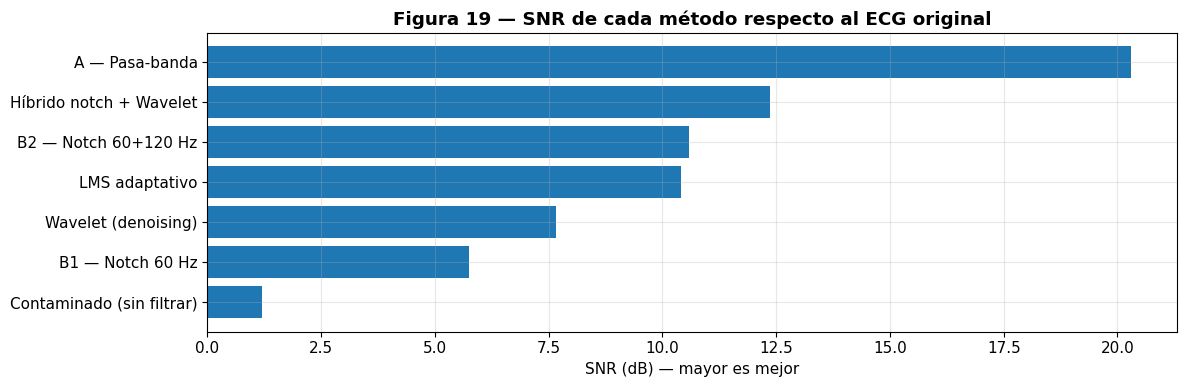

In [28]:
tabla_final = pd.DataFrame(resultados).T
tabla_final["Mejora SNR vs contaminado (dB)"] = tabla_final["SNR (dB)"] - tabla_final.loc["Contaminado (sin filtrar)", "SNR (dB)"]
display(tabla_final.round(4).sort_values("SNR (dB)", ascending=False))

# Gráfico de barras de SNR
plt.figure(figsize=(12, 4))
orden = tabla_final.sort_values("SNR (dB)")
plt.barh(orden.index, orden["SNR (dB)"], color="tab:blue")
plt.xlabel("SNR (dB) — mayor es mejor")
plt.title("Figura 19 — SNR de cada método respecto al ECG original")
plt.tight_layout(); plt.show()

### Comparación cualitativa

| Criterio | Pasa-banda | Notch | LMS adaptativo | Wavelet | Híbrido |
|---|---|---|---|---|---|
| Reducción de interferencias | Alta | Alta en 60 y 120 Hz | Alta después de converger | Parcial | Alta |
| Reducción de ruido gaussiano | Alta para frecuencias fuera de la banda | Baja | Baja | Moderada | Moderada |
| Conservación de la morfología | Alta, con ligero suavizado | Muy alta | Alta | Media | Alta |
| Distorsión introducida | Baja | Muy baja | Baja | Moderada | Baja |
| Complejidad | Baja | Baja | Media | Media | Media |
| ¿Qué necesita conocer? | Banda del ECG | Frecuencias de interferencia | Señales de referencia y paso de adaptación | Wavelet, nivel y umbral | Frecuencias y parámetros Wavelet |

En este registro, el pasa-banda obtuvo la mayor SNR. Sin embargo, el notch presentó una menor modificación de la señal original. Esto muestra que la selección del filtro no debe realizarse usando solamente una métrica.


---
# 🟦 BLOQUE 7 — Retroalimentación, síntesis e infografía

## 📝 Actividad de análisis

**Pregunta 1. ¿Por qué es importante conocer la frecuencia de muestreo de una señal biomédica?**

✍️ **Respuesta:** Permite construir correctamente el eje temporal y conocer la frecuencia máxima que puede analizarse sin producir aliasing. En nuestro registro se utilizaron 1000 muestras por segundo.

**Pregunta 2. ¿Qué diferencia existe entre ruido e interferencia?**

✍️ **Respuesta:** El ruido presenta un comportamiento más aleatorio y puede distribuirse en distintas frecuencias. La interferencia tiene un origen y una estructura reconocibles, como la componente de 60 Hz de la red eléctrica.

**Pregunta 3. ¿Por qué una interferencia sinusoidal puede observarse como un pico en el dominio de la frecuencia?**

✍️ **Respuesta:** Porque su energía se concentra alrededor de una frecuencia determinada. Por eso, las componentes agregadas se observaron como picos en 60 y 120 Hz.

**Pregunta 4. ¿Qué sucede cuando aplicamos un filtro demasiado agresivo a una señal ECG?**

✍️ **Respuesta:** Puede eliminar el ruido, pero también componentes útiles del ECG. Si la frecuencia de corte superior disminuye demasiado, los complejos QRS pueden perder amplitud y verse más redondeados.

**Pregunta 5. ¿Cuál es la principal diferencia conceptual entre un filtro convencional y un filtro adaptativo?**

✍️ **Respuesta:** El filtro convencional mantiene coeficientes fijos. El filtro adaptativo modifica sus coeficientes durante el procesamiento para aproximarse a una interferencia de referencia.

**Pregunta 6. ¿Para qué sirve la Transformada Wavelet?**

✍️ **Respuesta:** Sirve para separar una señal en componentes de distintas escalas y observar cómo cambian en el tiempo. También puede utilizarse para reducir ruido mediante la umbralización de sus coeficientes.

**Pregunta 7. ¿Por qué la Transformada Wavelet puede resultar útil para analizar señales biomédicas?**

✍️ **Respuesta:** Porque las señales biomédicas contienen eventos que aparecen en momentos específicos. En el ECG permite analizar componentes rápidas, como el QRS, y componentes más lentas, como la línea de base.

**Pregunta 8. ¿Qué información podría perderse durante el proceso de filtrado?**

✍️ **Respuesta:** Se puede perder parte de la amplitud, componentes de baja frecuencia, detalles rápidos del QRS o pequeñas ondas P y T. Esto ocurre cuando el filtro también elimina frecuencias pertenecientes al ECG.

**Pregunta 9. Si conoces la frecuencia exacta de una interferencia, ¿qué tipo de filtro podrías utilizar?**

✍️ **Respuesta:** Se puede utilizar un filtro notch centrado en la frecuencia de la interferencia. En esta práctica se aplicaron filtros notch en 60 y 120 Hz.

**Pregunta 10. ¿Por qué no debemos evaluar un filtro únicamente observando visualmente la señal?**

✍️ **Respuesta:** Una señal puede verse más limpia y aun así haber perdido información. Por eso también se deben revisar medidas como RMSE, SNR y correlación, además de observar la conservación de la morfología.


## 🧠 SUMARIZE — ¿Qué aprendimos?

1. La señal de actividad física presentaba mayor variación de amplitud, ruido y una línea de base menos estable.
2. Se agregaron interferencias de 60 y 120 Hz, además de ruido gaussiano.
3. Se aplicaron filtros pasa-banda, notch, LMS, Wavelet y un método híbrido.
4. El pasa-banda obtuvo la mayor SNR, con 20,2939 dB, y una correlación de 0,9954.
5. El filtro adaptativo utiliza referencias para estimar interferencias y modifica sus coeficientes durante el procesamiento.
6. Wavelet permite analizar componentes localizadas y reducir ruido mediante umbralización.
7. Para esta señal utilizaría el pasa-banda porque presentó el mejor resultado cuantitativo, verificando también que la morfología del ECG se conserve.

## 🎨 Actividad final — Infografía científica

La infografía debe presentar:

1. **Señal original:** ECG durante actividad física, adquirido mediante BITalino/OpenSignals a 1000 Hz, con una duración de 27,15 segundos y almacenado en el canal A1.
2. **Contaminación:** interferencia de 60 Hz con amplitud de 0,111 mV, interferencia de 120 Hz con amplitud de 0,066 mV y ruido gaussiano con desviación estándar de 0,033 mV.
3. **Filtrado:** comparación del pasa-banda, notch, LMS, Wavelet y método híbrido.
4. **Resultado:** el pasa-banda obtuvo una SNR de 20,2939 dB y una correlación de 0,9954.
5. **Conceptos clave:** ruido, interferencia, filtro convencional, filtro adaptativo, Wavelet y *denoising*.
6. **Conclusión:** comparación entre reducción del ruido y conservación de la morfología del ECG.

```text
ECG REAL → CONTAMINACIÓN → ANÁLISIS → FILTRADO → LMS → WAVELET → COMPARACIÓN → CONCLUSIONES
```

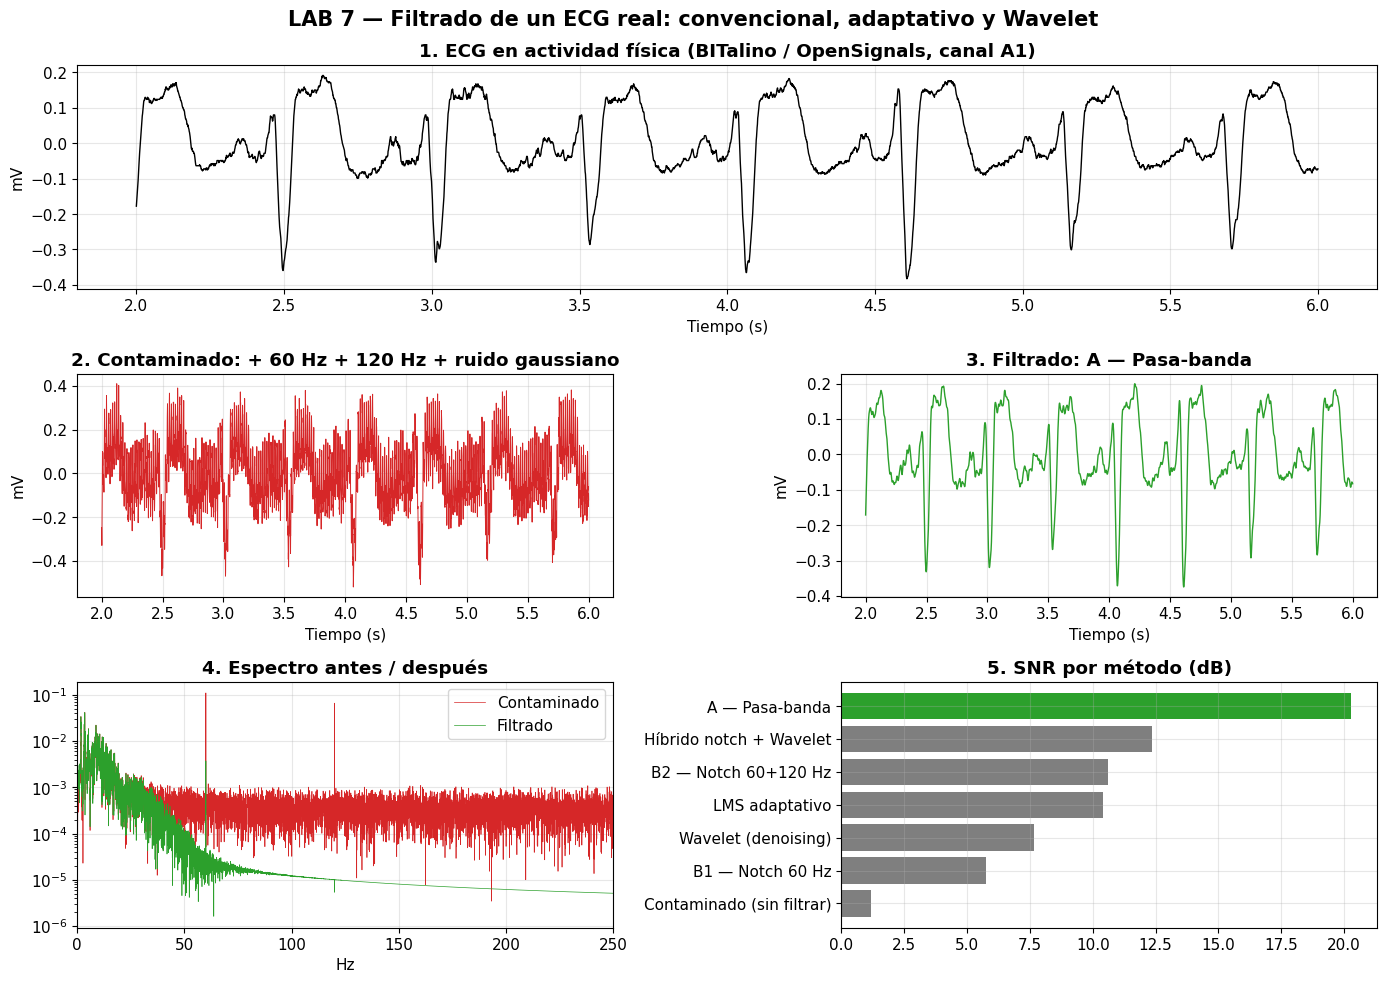

Figura guardada como 'figura_base_infografia_actividad_fisica.png'


In [29]:
# Elige el método que consideres mejor para la infografía (cambia la clave si lo deseas)
METODO_ELEGIDO = "A — Pasa-banda"
senales_metodos = {
    "A — Pasa-banda": ecg_pasabanda,
    f"B2 — Notch {f1}+{f2} Hz": ecg_notch_f1f2,
    "LMS adaptativo": ecg_lms,
    "Wavelet (denoising)": ecg_wavelet,
    "Híbrido notch + Wavelet": ecg_hibrido,
}
ecg_elegido = senales_metodos[METODO_ELEGIDO]

fig = plt.figure(figsize=(14, 10))
grid = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.1])

ax1 = fig.add_subplot(grid[0, :])
ax1.plot(t[zoom], ecg_original[zoom], color="black", lw=1)
ax1.set_title("1. ECG en actividad física (BITalino / OpenSignals, canal A1)")

ax2 = fig.add_subplot(grid[1, 0])
ax2.plot(t[zoom], ecg_contaminado[zoom], color="tab:red", lw=0.7)
ax2.set_title(f"2. Contaminado: + {f1} Hz + {f2} Hz + ruido gaussiano")

ax3 = fig.add_subplot(grid[1, 1])
ax3.plot(t[zoom], ecg_elegido[zoom], color="tab:green", lw=1)
ax3.set_title(f"3. Filtrado: {METODO_ELEGIDO}")

ax4 = fig.add_subplot(grid[2, 0])
ax4.semilogy(freq, amp_contaminado, color="tab:red", lw=0.5, label="Contaminado")
fr_e, am_e = espectro_amplitud(ecg_elegido, Fs)
ax4.semilogy(fr_e, am_e, color="tab:green", lw=0.5, label="Filtrado")
ax4.set_xlim(0, F_MAX_GRAFICO); ax4.legend(); ax4.set_xlabel("Hz")
ax4.set_title("4. Espectro antes / después")

ax5 = fig.add_subplot(grid[2, 1])
orden = tabla_final.sort_values("SNR (dB)")
colores = ["tab:green" if nombre == METODO_ELEGIDO else "tab:gray" for nombre in orden.index]
ax5.barh(orden.index, orden["SNR (dB)"], color=colores)
ax5.set_title("5. SNR por método (dB)")

for eje in (ax1, ax2, ax3):
    eje.set_xlabel("Tiempo (s)"); eje.set_ylabel("mV")
fig.suptitle("LAB 7 — Filtrado de un ECG real: convencional, adaptativo y Wavelet", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("figura_base_infografia_actividad_fisica.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada como 'figura_base_infografia_actividad_fisica.png'")


## 🔁 Guía de retroalimentación para el docente (últimos 30 min)

| Momento | Actividad |
|---|---|
| min 90 – 95 | Cierre de la discusión Wavelet: ¿por qué sobrevivieron las interferencias al umbral? |
| min 95 – 105 | Revisar la tabla final y la Figura 19: comparar filtros; contrastar métricas con lo visual. |
| min 105 – 112 | Discutir errores frecuentes y revisar respuestas a las preguntas 1 – 10. |
| min 112 – 120 | Revisar avance de la síntesis e infografía; responder preguntas. |

**Errores frecuentes a discutir:**
- Graficar `nSeq` o las columnas digitales como si fueran ECG.
- Usar `nSeq` como eje de tiempo.
- Confundir ruido (aleatorio, banda ancha) con interferencia (estructurada, banda estrecha).
- Elegir un pasa-bajas con corte muy bajo y "aplanar" el QRS.
- Interpretar que una SNR alta garantiza una morfología clínicamente correcta.
- Olvidar que el LMS necesita un tiempo de convergencia.
- Asumir que la Wavelet elimina cualquier tipo de contaminación.

**Ideas clave para el cierre:**
- Filtro **convencional**: coeficientes fijos, efectivo si conocemos la banda del ruido.
- Filtro **adaptativo**: coeficientes que cambian, requiere una referencia, sigue interferencias variables.
- **Wavelet**: análisis tiempo-escala, útil para eventos localizados (QRS) y ruido de banda ancha.
- En la práctica se **combinan** técnicas según el problema.

## ✅ Conclusiones del laboratorio

La señal ECG durante actividad física fue registrada en el canal A1 con una frecuencia de muestreo de 1000 Hz y una duración de 27,15 segundos. No se detectaron pérdidas de muestras, pero se observaron más variaciones de amplitud y ruido relacionados con el movimiento. Al agregar interferencias de 60 y 120 Hz y ruido gaussiano, la identificación visual de las ondas se volvió más difícil. El filtro pasa-banda obtuvo el mejor resultado cuantitativo, con una SNR de 20,2939 dB y una correlación de 0,9954. Los filtros notch conservaron mejor la forma original, aunque redujeron menos el ruido distribuido en varias frecuencias. El LMS canceló las interferencias después de un periodo de adaptación, mientras que Wavelet permitió trabajar con componentes localizados de la señal. Finalmente, la elección del método debe considerar tanto las métricas como la conservación de la morfología del ECG.

---
# 📦 ENTREGA

### 1. Jupyter Notebook (`.ipynb`)
Debe contener:
- código ejecutado sin errores;
- todos los gráficos generados;
- respuestas a las preguntas de cada bloque y a las 10 preguntas de análisis;
- interpretación de resultados;
- sección *SUMARIZE* y conclusiones.

### 2. Infografía (PDF o PNG)
Debe sintetizar el flujo completo:

```text
ECG REAL
   ↓
CONTAMINACIÓN
   ↓
ANÁLISIS
   ↓
FILTRADO
   ↓
FILTRO ADAPTATIVO
   ↓
WAVELET
   ↓
COMPARACIÓN
   ↓
CONCLUSIONES
```

**Nombre de archivos sugerido:** `LAB7_Apellido_Nombre.ipynb` y `LAB7_Apellido_Nombre_infografia.pdf`

# 📊 Criterios de evaluación

| Criterio | Peso | Logrado (100%) | En proceso (50%) | No logrado (0%) |
|---|---:|---|---|---|
| Carga y comprensión de datos | 15% | Lee cabecera, identifica A1, construye `t` correctamente y justifica no usar `nSeq`. | Carga los datos con errores menores de interpretación. | No identifica el canal ECG o usa un eje temporal incorrecto. |
| Contaminación artificial | 15% | Genera y visualiza ambas interferencias y el ruido; interpreta el espectro. | Genera la contaminación pero la interpretación es incompleta. | No genera la contaminación o no la analiza. |
| Aplicación de filtros | 20% | Aplica pasa-banda y notch, muestra respuestas en frecuencia y explica efectos. | Aplica los filtros sin justificar parámetros. | No aplica los filtros correctamente. |
| Análisis e interpretación | 20% | Integra métricas y observación visual; reconoce distorsiones y limitaciones. | Interpretación superficial o solo visual. | Sin interpretación. |
| Filtro adaptativo y Wavelet | 15% | Explica el LMS (referencia, error, coeficientes) y el denoising Wavelet; experimenta con parámetros. | Ejecuta el código sin explicar los conceptos. | No aborda estos métodos. |
| Infografía y comunicación | 15% | Infografía clara, completa (6 secciones) y con conclusión fundamentada. | Infografía incompleta o poco clara. | No entrega infografía. |
| **Total** | **100%** | | | |
